# Evaluación de Variantes — CatBoost Final (BAF NeurIPS 2022)

**Hiperparámetros fijados por Optuna (trial 23, AP_CV=0.1734):**

- **iterations**   = 622
- **depth**         = 4
- **learning_rate** = 0.03965
- **l2_leaf_reg**   = 7
- **border_count**  = 116
- **random_strength** = 1.44e-06


El modelo se entrena una sola vez sobre el **100% del train de Base**.
Las variantes se evalúan completas — son datasets de test por definición.



## 1. Importaciones

Cargamos todas las librerías que vamos a necesitar a lo largo del notebook. 


In [1]:
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import RobustScaler
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score, precision_recall_curve,
    f1_score, recall_score, precision_score, roc_auc_score,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, precision_recall_curve,
    average_precision_score, classification_report
)
from catboost import CatBoostClassifier, Pool
import warnings
warnings.filterwarnings('ignore')
import dice_ml
from dice_ml import Dice
import pandas as pd
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

RANDOM_STATE = 42
TARGET_COL   = 'fraud_bool'


### 1.1 Rutas de los datasets

Definimos el diccionario con las rutas de los seis archivos CSV: el dataset base y las cinco variantes del benchmark BAF (NeurIPS 2022). 
Después hacemos un chequeo rápido para confirmar que todos los ficheros están presentes en disco antes de continuar, 
si alguno falta, aparecerá marcado como `FALTA` para detectarlo a tiempo.

In [2]:
DATASET_PATHS = {
    'Base':        'base-limpia.csv',
    'Variant I':   'v1-tratado.csv',
    'Variant II':  'v2-tratado.csv',
    'Variant III': 'v3-tratado.csv',
    'Variant IV':  'v4-tratado.csv',
    'Variant V':   'v5-tratado.csv',
}

for name, path in DATASET_PATHS.items():
    import os
    status = 'OK' if os.path.exists(path) else 'FALTA'
    print(f'  [{status}]  {name}: {path}')

  [OK]  Base: base-limpia.csv
  [OK]  Variant I: v1-tratado.csv
  [OK]  Variant II: v2-tratado.csv
  [OK]  Variant III: v3-tratado.csv
  [OK]  Variant IV: v4-tratado.csv
  [OK]  Variant V: v5-tratado.csv



## 2. Carga del dataset Base y split 80/20

Leemos el CSV tratado de Base y separamos features del target (`fraud_bool`). 
Hacemos un split estratificado 80/20 para conservar la proporción de fraude en ambas particiones. 

In [3]:
df_base = pd.read_csv('base-limpia.csv')
X_base  = df_base.drop(columns=[TARGET_COL])
y_base  = df_base[TARGET_COL]

X_train, X_test_base, y_train, y_test_base = train_test_split(
    X_base, y_base,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_base,
)

Calculamos el ratio de desbalanceo entre clases (legítimos vs. fraudes) y lo imprimimos junto con el tamaño de cada partición. 
Este ratio lo usaremos después como `scale_pos_weight` en CatBoost para compensar el desbalanceo sin necesidad de sobremuestreo.

In [4]:
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()

print(f'base-limpia.csv cargado  : {df_base.shape[0]:,} filas')
print(f'Train (100%)      : {X_train.shape[0]:,} muestras ({y_train.mean()*100:.2f}% fraude)')
print(f'Test Base (20%)   : {X_test_base.shape[0]:,} muestras ({y_test_base.mean()*100:.2f}% fraude)')
print(f'Ratio 0:1         : {ratio_desbalance:.1f}:1')

base-limpia.csv cargado  : 1,000,000 filas
Train (100%)      : 800,000 muestras (1.10% fraude)
Test Base (20%)   : 200,000 muestras (1.10% fraude)
Ratio 0:1         : 89.7:1



## 3. Entrenamiento del pipeline final

Aquí arranca el entrenamiento real. Los hiperparámetros que usamos son los que encontró Optuna en el trial 23, 
que consiguió un AP medio en validación cruzada de 0.1734. Los fijamos en un diccionario para tenerlos bien documentados 
y poder reproducir el modelo exactamente.

Primero se inicializan los mejores parámetros para poder configurar el mejor modelo

In [5]:
BEST_PARAMS = {
    'iterations':     622,
    'depth':          4,
    'learning_rate':  0.03965120054095257,
    'l2_leaf_reg':    7,
    'border_count':   116,
    'random_strength':1.443642998434956e-06,
}

Creación del **Pipeline** final para poder el entreno con el 100% del dataset.

In [6]:
final_pipeline = ImbPipeline(steps=[
    ('model',  CatBoostClassifier(
        **BEST_PARAMS,
        scale_pos_weight=ratio_desbalance,
        random_seed=RANDOM_STATE,
        eval_metric='PRAUC',
        thread_count=-1,
        verbose=False,
    )),
])

Lanzamos el entrenamiento sobre el 80% de los datos de Base. 
CatBoost usa todos los hilos disponibles (`thread_count=-1`) y ajusta el peso de la clase positiva 
con el ratio calculado antes, así no hace falta SMOTE ni ningún otro remuestreo en el pipeline final.

In [7]:
print('Entrenando pipeline final sobre el 100% del train...')
print(f'  Hiperparametros: {BEST_PARAMS}')
t0 = time.time()
final_pipeline.fit(X_train, y_train)
print(f'  Completado en {time.time()-t0:.1f}s')
print()
print('Pipeline listo')

Entrenando pipeline final sobre el 100% del train...
  Hiperparametros: {'iterations': 622, 'depth': 4, 'learning_rate': 0.03965120054095257, 'l2_leaf_reg': 7, 'border_count': 116, 'random_strength': 1.443642998434956e-06}
  Completado en 91.7s

Pipeline listo



## 4. Funciones auxiliares

Antes de evaluar nada, definimos las dos funciones de utilidad que usaremos a lo largo de todo el análisis. 
Separarlas aquí facilita reutilizarlas sin repetir código.

### 4.1 Búsqueda del umbral óptimo

En detección de fraude el umbral por defecto de 0.5 casi nunca es el mejor, el desbalanceo entre clases hace que haya que ajustarlo. 
Esta función recorre todos los puntos de la curva Precision-Recall, calcula el F1 en cada uno y devuelve el umbral donde ese F1 es máximo. 
Es la forma más directa de encontrar el punto de operación que mejor equilibra precisión y cobertura.

In [8]:
def find_best_threshold(y_true, y_proba):
    """Umbral que maximiza F1 en la curva Precision-Recall."""
    prec, rec, thr = precision_recall_curve(y_true, y_proba)
    f1  = 2 * (prec * rec) / (prec + rec + 1e-10)
    idx = np.argmax(f1[:-1])
    return float(thr[idx]) if len(thr) > idx else 0.5


### 4.2 Evaluación por variante

Esta es la función central del notebook. Recibe el pipeline ya entrenado y un dataset de evaluación, 
obtiene las probabilidades predichas y calcula todas las métricas que nos interesan: AP, ROC-AUC, F1, Recall y Precision, estas tres últimas aplicando el umbral óptimo calculado antes. 

También mide el tiempo de inferencia y devuelve un diccionario con todo, incluyendo las probabilidades crudas para poder pintar curvas PR después.

In [9]:
def evaluate_variant(pipeline, name, X_eval, y_eval):
    """
    Pasa X_eval por el pipeline y devuelve todas las métricas.
    El pipeline aplica RobustScaler.transform() y CatBoost.predict_proba().
    SMOTE no interviene — solo actua en .fit().
    """
    t0      = time.time()
    y_proba = pipeline.predict_proba(X_eval)[:, 1]

    ap      = average_precision_score(y_eval, y_proba)
    roc_auc = roc_auc_score(y_eval, y_proba)
    thr     = find_best_threshold(y_eval, y_proba)
    y_pred  = (y_proba >= thr).astype(int)
    f1      = f1_score(y_eval, y_pred, zero_division=0)
    rec     = recall_score(y_eval, y_pred, zero_division=0)
    prec    = precision_score(y_eval, y_pred, zero_division=0)
    fraud_r = float(np.asarray(y_eval).mean()) * 100

    print(f'  {name:<14} | AP={ap:.4f} | F1={f1:.4f} | '
          f'Recall={rec:.4f} | Precision={prec:.4f} | '
          f'Fraude={fraud_r:.2f}% | {time.time()-t0:.1f}s')

    return {
        'Variante':  name,
        'AP':        round(ap, 4),
        'ROC-AUC':   round(roc_auc, 4),
        'F1':        round(f1, 4),
        'Recall':    round(rec, 4),
        'Precision': round(prec, 4),
        'Threshold': round(thr, 4),
        'Fraude_%':  round(fraud_r, 3),
        'N_eval':    len(y_eval),
        '_y_proba':  y_proba,
        '_y_true':   np.asarray(y_eval),
    }

## 5. Evaluación sobre Base y las 5 variantes

Aquí evaluamos el modelo entrenado contra cada dataset. Primero lo pasamos por el test de Base, el 20% que separamos al principio,
y después por cada una de las variantes completas, que por definición son datasets de test independientes, no se usan para entrenar.

Para las variantes hay un paso previo de alineación: si las columnas categóricas vienen como strings en lugar de enteros, 
las codificamos al vuelo con el mismo esquema que se usó en Base (one-hot para `payment_type`, `source` y `device_os`; 
mapeo ordinal para `employment_status` y `housing_status`). Al final reindexamos para garantizar que el orden de columnas sea exactamente el mismo que vio el modelo durante el entrenamiento.

In [10]:
print('=' * 70)
print('PIPELINE DE EVALUACION — CatBoost Final vs. Variantes BAF')
print('=' * 70)
print(f"  {'Variante':<14} | {'AP':>6} | {'F1':>6} | {'Recall':>6} | "
      f"{'Precision':>9} | {'Fraude%':>7} | Tiempo")
print('-' * 70)

all_results = []
t_global    = time.time()

all_results.append(evaluate_variant(
    final_pipeline, 'Base', X_test_base, y_test_base
))

# Mapeos extraídos del EDA corregido, para alinear las variantes a la codificación de Base
EMP_MAP = {'CA':0,'CB':1,'CC':2,'CD':3,'CE':4,'CF':5,'CG':6}
HOU_MAP = {'BA':0,'BB':1,'BC':2,'BD':3,'BE':4,'BF':5,'BG':6}
TRAIN_COLS = X_train.columns.tolist()

# Evaluamos cada variante
for variant_name, csv_path in list(DATASET_PATHS.items())[1:]:
    if not os.path.exists(csv_path):
        print(f'  AVISO: {csv_path} no encontrado — se omite.')
        continue

    df_v = pd.read_csv(csv_path)
    X_v  = df_v.drop(columns=[TARGET_COL])
    y_v  = df_v[TARGET_COL]

    # Codificacion on-the-fly alineada a Base
    if 'payment_type' in X_v.columns:
        dum = pd.get_dummies(X_v['payment_type'], prefix='payment_type', dtype=int)
        if 'payment_type_AA' in dum.columns: dum = dum.drop(columns=['payment_type_AA'])
        X_v = X_v.drop(columns=['payment_type']).join(dum)

    if 'source' in X_v.columns:
        dum = pd.get_dummies(X_v['source'], prefix='source', dtype=int)
        if 'source_INTERNET' in dum.columns: dum = dum.drop(columns=['source_INTERNET'])
        X_v = X_v.drop(columns=['source']).join(dum)

    if 'device_os' in X_v.columns:
        dum = pd.get_dummies(X_v['device_os'], prefix='device_os', dtype=int)
        if 'device_os_linux' in dum.columns: dum = dum.drop(columns=['device_os_linux'])
        X_v = X_v.drop(columns=['device_os']).join(dum)

    if X_v['employment_status'].dtype == object:
        X_v['employment_status'] = X_v['employment_status'].map(EMP_MAP)

    if X_v['housing_status'].dtype == object:
        X_v['housing_status'] = X_v['housing_status'].map(HOU_MAP)

    X_v = X_v.reindex(columns=TRAIN_COLS, fill_value=0)

    all_results.append(evaluate_variant(final_pipeline, variant_name, X_v, y_v))

print('-' * 70)
print(f'  Tiempo total: {time.time()-t_global:.1f}s')
print('=' * 70)


PIPELINE DE EVALUACION — CatBoost Final vs. Variantes BAF
  Variante       |     AP |     F1 | Recall | Precision | Fraude% | Tiempo
----------------------------------------------------------------------
  Base           | AP=0.1842 | F1=0.2494 | Recall=0.2684 | Precision=0.2330 | Fraude=1.10% | 0.3s
  Variant I      | AP=0.1318 | F1=0.2021 | Recall=0.2435 | Precision=0.1727 | Fraude=1.10% | 1.5s
  Variant II     | AP=0.1634 | F1=0.2330 | Recall=0.2536 | Precision=0.2156 | Fraude=1.10% | 1.3s
  Variant III    | AP=0.1159 | F1=0.1880 | Recall=0.2269 | Precision=0.1605 | Fraude=1.10% | 1.3s
  Variant IV     | AP=0.1470 | F1=0.2193 | Recall=0.2688 | Precision=0.1852 | Fraude=1.10% | 1.2s
  Variant V      | AP=0.1168 | F1=0.1869 | Recall=0.2263 | Precision=0.1592 | Fraude=1.10% | 1.3s
----------------------------------------------------------------------
  Tiempo total: 32.3s



## 6. Tabla comparativa de resultados

Definimos la paleta de colores que identificará a cada variante en todos los gráficos del notebook. 
Mantener un color fijo por variante facilita comparar visualmente los distintos plots sin tener que releer leyendas.

In [11]:
PALETTE = {
    'Base':        '#2ecc71',
    'Variant I':   '#3498db',
    'Variant II':  '#e67e22',
    'Variant III': '#e74c3c',
    'Variant IV':  '#9b59b6',
    'Variant V':   '#1a252f',
}

Construimos el DataFrame final con todas las métricas y añadimos dos columnas de delta respecto a Base: 
`Delta_AP_pp` y `Delta_F1_pp`, expresadas en puntos porcentuales. 
Un valor positivo significa que esa variante le va mejor al modelo que el propio test de Base, uno negativo indica degradación. 
La tabla se muestra primero en texto plano y después con formato estilizado (colores por fila y deltas en verde/rojo).

In [12]:
cols = ['Variante','AP','ROC-AUC','F1','Recall','Precision','Threshold','Fraude_%','N_eval']
df_results = pd.DataFrame(
    [{k: v for k,v in r.items() if not k.startswith('_')} for r in all_results]
)[cols]

base_ap = df_results.loc[df_results['Variante']=='Base','AP'].values[0]
base_f1 = df_results.loc[df_results['Variante']=='Base','F1'].values[0]
df_results['Delta_AP_pp'] = ((df_results['AP'] - base_ap) * 100).round(2)
df_results['Delta_F1_pp'] = ((df_results['F1'] - base_f1) * 100).round(2)

print('TABLA COMPARATIVA FINAL')
print('=' * 75)
print(df_results.to_string(index=False))
print('=' * 75)

try:
    def highlight_row(row):
        bg = PALETTE.get(row['Variante'], '#ffffff')
        return [f'background-color: {bg}18'] * len(row)

    def color_delta(val):
        if pd.isna(val) or val == 0: return 'color: black'
        return 'color: #27ae60; font-weight:bold' if val > 0 else 'color: #e74c3c; font-weight:bold'

    fmt = {c: '{:.4f}' for c in ['AP','ROC-AUC','F1','Recall','Precision','Threshold']}
    fmt.update({'Fraude_%': '{:.3f}%', 'N_eval': '{:,}',
                'Delta_AP_pp': '{:+.2f} pp', 'Delta_F1_pp': '{:+.2f} pp'})

    display(
        df_results.style
        .apply(highlight_row, axis=1)
        .map(color_delta, subset=['Delta_AP_pp','Delta_F1_pp'])
        .format(fmt)
        .set_caption('CatBoost Final — Base vs. Variantes BAF (NeurIPS 2022)')
        .set_table_styles([{'selector':'th',
                            'props':[('background-color','#2c3e50'),
                                     ('color','white'),('text-align','center')]}])
    )
except Exception:
    pass


TABLA COMPARATIVA FINAL
   Variante     AP  ROC-AUC     F1  Recall  Precision  Threshold  Fraude_%  N_eval  Delta_AP_pp  Delta_F1_pp
       Base 0.1842   0.8991 0.2494  0.2684     0.2330     0.9154     1.103  200000         0.00         0.00
  Variant I 0.1318   0.8720 0.2021  0.2435     0.1727     0.9269     1.103 1000000        -5.24        -4.73
 Variant II 0.1634   0.8903 0.2330  0.2536     0.2156     0.9564     1.103 1000000        -2.08        -1.64
Variant III 0.1159   0.8630 0.1880  0.2269     0.1605     0.9508     1.103 1000000        -6.83        -6.14
 Variant IV 0.1470   0.8854 0.2193  0.2688     0.1852     0.9508     1.103 1000000        -3.72        -3.01
  Variant V 0.1168   0.8656 0.1869  0.2263     0.1592     0.9507     1.103 1000000        -6.74        -6.25


,Variante,AP,ROC-AUC,F1,Recall,Precision,Threshold,Fraude_%,N_eval,Delta_AP_pp,Delta_F1_pp
0,Base,0.1842,0.8991,0.2494,0.2684,0.2330,0.9154,1.103%,"200,000",+0.00 pp,+0.00 pp
1,Variant I,0.1318,0.8720,0.2021,0.2435,0.1727,0.9269,1.103%,"1,000,000",-5.24 pp,-4.73 pp
2,Variant II,0.1634,0.8903,0.2330,0.2536,0.2156,0.9564,1.103%,"1,000,000",-2.08 pp,-1.64 pp
3,Variant III,0.1159,0.8630,0.1880,0.2269,0.1605,0.9508,1.103%,"1,000,000",-6.83 pp,-6.14 pp
4,Variant IV,0.1470,0.8854,0.2193,0.2688,0.1852,0.9508,1.103%,"1,000,000",-3.72 pp,-3.01 pp
5,Variant V,0.1168,0.8656,0.1869,0.2263,0.1592,0.9507,1.103%,"1,000,000",-6.74 pp,-6.25 pp



## 7. Visualizaciones del análisis comparativo

Generamos un panel de 6 gráficos en una sola figura para tener una visión completa de cómo se comporta el modelo en cada dataset:

- **AP por variante** — barras con línea de referencia de Base.
- **F1 por variante** — ídem para el F1 con umbral óptimo.
- **Scatter Recall vs. Precision** — muestra el trade-off de cada variante en un mismo plano.
- **Delta AP respecto a Base** — barras en verde/rojo según si el modelo mejora o empeora.
- **Curvas PR superpuestas** — la curva completa de cada variante en un mismo eje.
- **Heatmap de métricas normalizado** — permite comparar de un vistazo qué variante puntúa mejor en cada métrica.

El conjunto se guarda también como PNG de alta resolución.

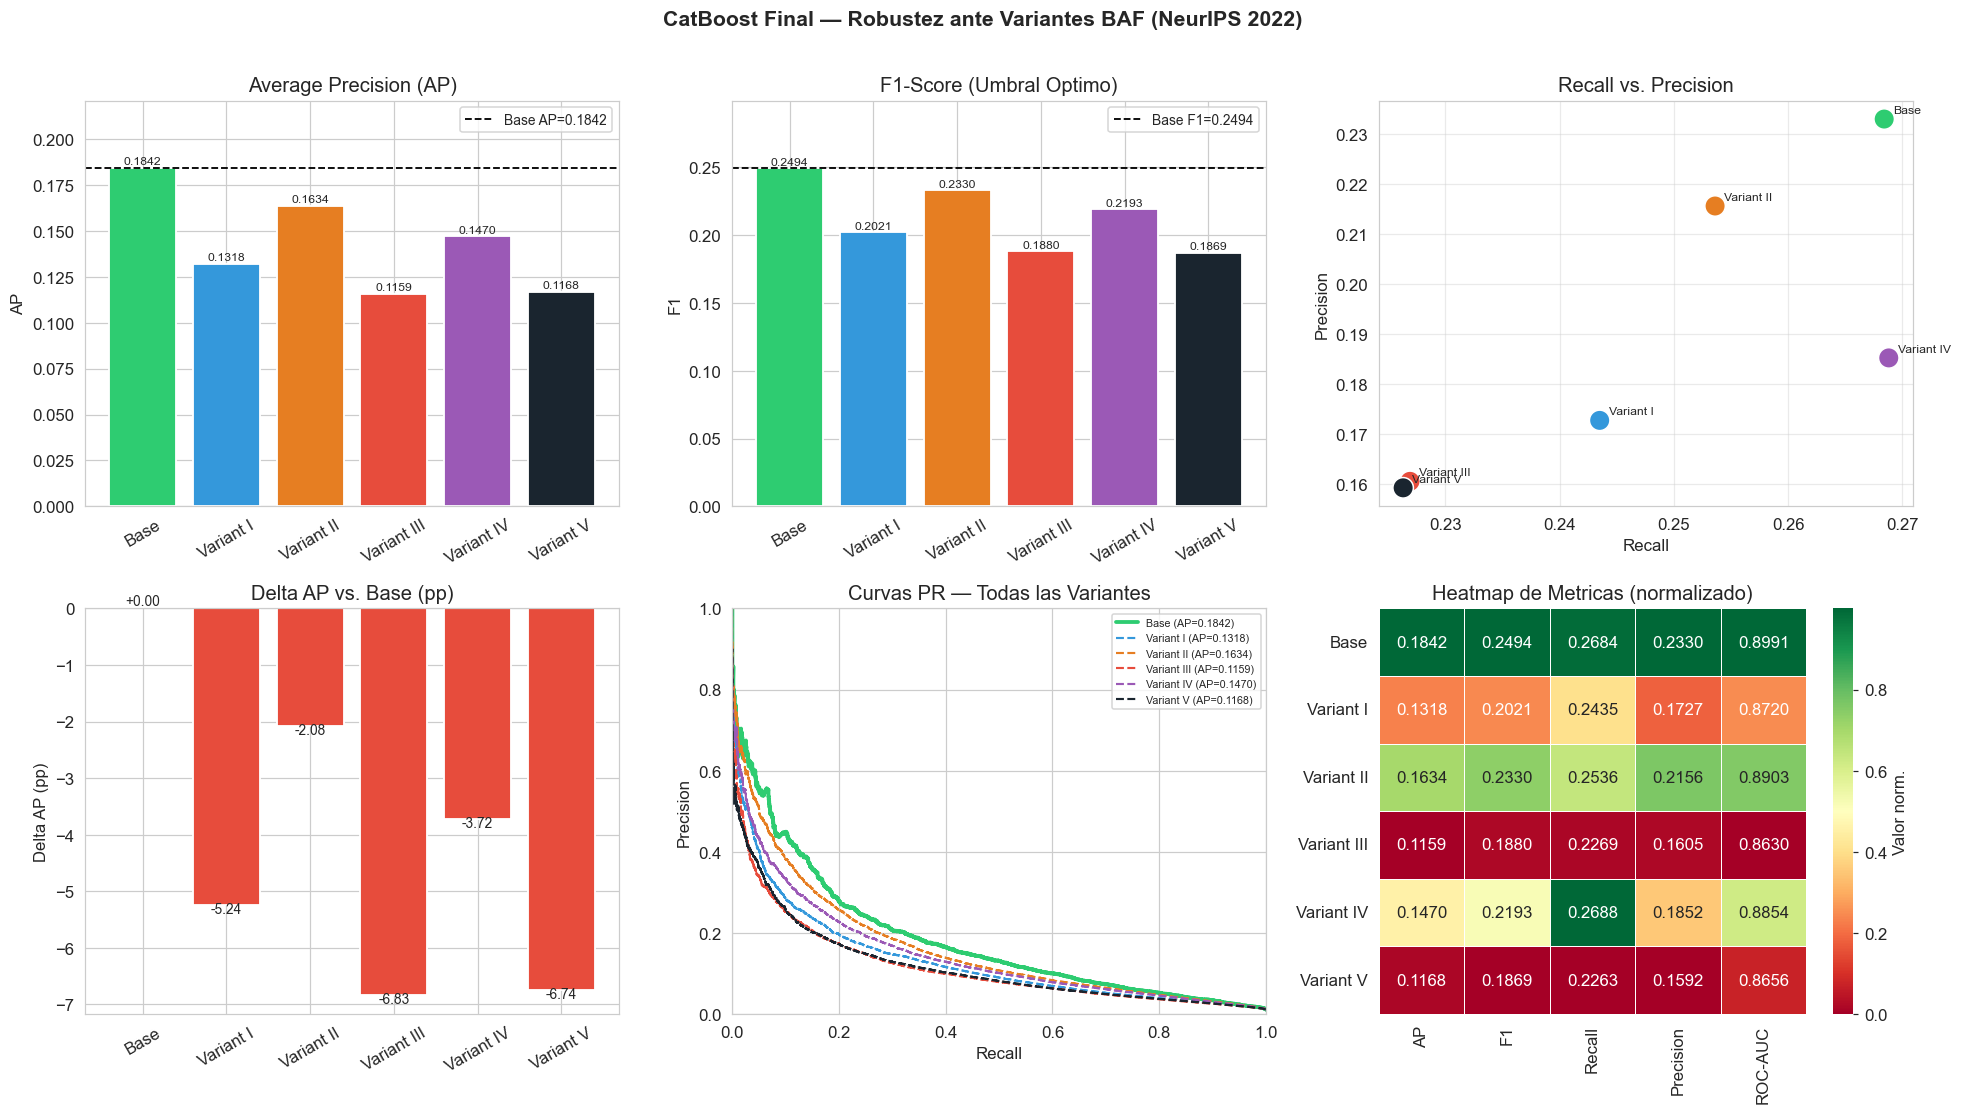

Grafico guardado -> evaluacion_variantes_catboost_final.png


In [13]:
variants   = df_results['Variante'].tolist()
colors_bar = [PALETTE.get(v,'#95a5a6') for v in variants]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('CatBoost Final — Robustez ante Variantes BAF (NeurIPS 2022)',
             fontsize=14, fontweight='bold', y=1.01)

# 1. AP por variante
ax = axes[0,0]
bars = ax.bar(variants, df_results['AP'], color=colors_bar, edgecolor='white', linewidth=1.2)
ax.axhline(base_ap, color='black', linestyle='--', linewidth=1.2,
           label=f'Base AP={base_ap:.4f}')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_title('Average Precision (AP)'); ax.set_ylabel('AP')
ax.set_ylim(0, max(df_results['AP'])*1.20)
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30)

# 2. F1-Score
ax = axes[0,1]
bars = ax.bar(variants, df_results['F1'], color=colors_bar, edgecolor='white', linewidth=1.2)
ax.axhline(base_f1, color='black', linestyle='--', linewidth=1.2,
           label=f'Base F1={base_f1:.4f}')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
            f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_title('F1-Score (Umbral Optimo)'); ax.set_ylabel('F1')
ax.set_ylim(0, max(df_results['F1'])*1.20)
ax.legend(fontsize=9); ax.tick_params(axis='x', rotation=30)

# 3. Recall vs Precision scatter
ax = axes[0,2]
ax.scatter(df_results['Recall'], df_results['Precision'],
           c=colors_bar, s=180, edgecolors='white', zorder=3)
for _, row in df_results.iterrows():
    ax.annotate(row['Variante'], (row['Recall'], row['Precision']),
                textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Recall vs. Precision'); ax.grid(True, alpha=0.4)

# 4. Delta AP vs Base
ax = axes[1,0]
delta = df_results['Delta_AP_pp'].tolist()
bar_colors_d = ['#27ae60' if d>=0 else '#e74c3c' for d in delta]
bars = ax.bar(variants, delta, color=bar_colors_d, edgecolor='white', linewidth=1.2)
ax.axhline(0, color='black', linewidth=1)
for b in bars:
    yoff = 0.05 if b.get_height()>=0 else -0.15
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+yoff,
            f'{b.get_height():+.2f}', ha='center', fontsize=9)
ax.set_title('Delta AP vs. Base (pp)'); ax.set_ylabel('Delta AP (pp)')
ax.tick_params(axis='x', rotation=30)

# 5. Curvas PR superpuestas
ax = axes[1,1]
for r in all_results:
    prec_c, rec_c, _ = precision_recall_curve(r['_y_true'], r['_y_proba'])
    col = PALETTE.get(r['Variante'],'#95a5a6')
    lw  = 2.5 if r['Variante']=='Base' else 1.4
    ls  = '-'  if r['Variante']=='Base' else '--'
    ax.plot(rec_c, prec_c, color=col, linewidth=lw, linestyle=ls,
            label=f"{r['Variante']} (AP={r['AP']:.4f})")
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas PR — Todas las Variantes')
ax.legend(fontsize=7, loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1])

# 6. Heatmap normalizado
ax = axes[1,2]
hm_cols = ['AP','F1','Recall','Precision','ROC-AUC']
hm_data = df_results.set_index('Variante')[hm_cols]
hm_norm = (hm_data - hm_data.min()) / (hm_data.max() - hm_data.min() + 1e-10)
sns.heatmap(hm_norm, annot=hm_data.round(4), fmt='.4f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'Valor norm.'})
ax.set_title('Heatmap de Metricas (normalizado)'); ax.set_ylabel('')

plt.tight_layout()
plt.savefig('evaluacion_variantes_catboost_final.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grafico guardado -> evaluacion_variantes_catboost_final.png')


### 7.1 Funciones de visualización individuales

A continuación se definen las funciones reutilizables para cada tipo de gráfico. 
Todas siguen el mismo patrón: reciben los datos, generan la figura, la guardan en disco y la muestran en el notebook. 
Primero configuramos el estilo global que aplicarán todas.

In [14]:
def setup_plot_style():
    """Configuración profesional única para todos los gráficos"""
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'legend.fontsize': 10,
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.facecolor': 'white',
    })
    sns.set_style("whitegrid")
    sns.set_palette("viridis")

Función encargada de graficar la importacia de las variables.

In [26]:
def plot_feature_importance(model, X_train, top_n=20, output_path='img/feature_importance.png'):
    """Gráfico de importancia de variables"""
    importances = model.named_steps['model'].feature_importances_
    features = X_train.columns.tolist()
    
    imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
    imp_df = imp_df.sort_values('Importance', ascending=False).head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df)))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=colors, edgecolor='white')
    
    ax.set_xlabel('Importancia', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Variables Más Importantes', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f"Guardado: {output_path}")

Función encargada de plotear la distribucción de probabilidades de dos forma distintas

In [27]:
def plot_probability_distribution(y_true, y_proba, output_path='img/probability_distribution.png'):
    """Distribución de probabilidades (histograma + boxplot)"""
    legit_proba = y_proba[y_true == 0]
    fraud_proba = y_proba[y_true == 1]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histograma
    axes[0].hist(legit_proba, bins=50, alpha=0.6, label=f'Legítimos (n={len(legit_proba):,})', 
                 color='#2ecc71', density=True, edgecolor='white')
    axes[0].hist(fraud_proba, bins=50, alpha=0.6, label=f'Fraudes (n={len(fraud_proba):,})', 
                 color='#e74c3c', density=True, edgecolor='white')
    axes[0].axvline(x=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
    axes[0].set_xlabel('Probabilidad de Fraude')
    axes[0].set_ylabel('Densidad')
    axes[0].set_title('Distribución de Probabilidades')
    axes[0].legend()
    axes[0].set_yscale('log')
    
    # Boxplot
    bp = axes[1].boxplot([legit_proba, fraud_proba], labels=['Legítimos', 'Fraudes'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    axes[1].set_ylabel('Probabilidad de Fraude')
    axes[1].set_title('Comparativa de Probabilidades')
    axes[1].axhline(y=0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f" Guardado: {output_path}")

En esta función de se encarga de visualizar la **Curva ROC**

In [28]:
def plot_roc_curve(y_true, y_proba, output_path='img/roc_curve.png'):
    """Curva ROC"""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)
    
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(fpr, tpr, color='#3498db', linewidth=2.5, label=f'CatBoost (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador Aleatorio')
    ax.fill_between(fpr, tpr, alpha=0.2, color='#3498db')
    ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
    ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
    ax.set_title('Curva ROC')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f" Guardado: {output_path}")

Función encargada de plotear la curva **Precision-Recall**

In [29]:
def plot_pr_curve(y_true, y_proba, output_path='img/pr_curve.png'):
    """Curva Precision-Recall con threshold óptimo"""
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    ap_score = average_precision_score(y_true, y_proba)
    
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    best_idx = np.argmax(f1_scores[:-1])
    best_f1 = f1_scores[best_idx]
    
    fig, ax = plt.subplots(figsize=(8, 7))
    ax.plot(recall, precision, color='#e74c3c', linewidth=2.5, label=f'CatBoost (AP = {ap_score:.4f})')
    ax.scatter(recall[best_idx], precision[best_idx], color='#2ecc71', s=100, 
               zorder=5, label=f'Threshold óptimo (F1={best_f1:.4f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Curva Precision-Recall')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f"Guardado: {output_path}")

Función encargada de visualizar la matriz de confusión

In [30]:
def plot_confusion_matrix(y_true, y_proba, threshold, output_path='img/confusion_matrix.png'):
    """Matriz de confusión con threshold personalizado"""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Legítimo', 'Fraude'],
                yticklabels=['Legítimo', 'Fraude'],
                annot_kws={'size': 14}, ax=ax)
    ax.set_xlabel('Predicción', fontsize=12, fontweight='bold')
    ax.set_ylabel('Real', fontsize=12, fontweight='bold')
    ax.set_title(f'Matriz de Confusión (Threshold = {threshold:.4f})', fontsize=13, fontweight='bold')
    
    metrics_text = f'TP: {tp:,} | FP: {fp:,}\nFN: {fn:,} | TN: {tn:,}\n\nPrecisión: {tp/(tp+fp):.3f}\nRecall: {tp/(tp+fn):.3f}\nF1: {2*tp/(2*tp+fp+fn):.3f}'
    ax.text(1.15, 0.5, metrics_text, transform=ax.transAxes, fontsize=10,
            verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f"   Guardado: {output_path}")


Esta función se encarga de visualizar la comparativa AP por variantes

In [31]:

def plot_variants_comparison(df_results, output_path='img/variants_comparison.png'):
    """Comparativa de AP por variante"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    variants = df_results['Variante'].tolist()
    ap_scores = df_results['AP'].tolist()
    colors = ['#2ecc71' if v == 'Base' else '#e74c3c' if 'Variant III' in v or 'Variant V' in v else '#3498db' for v in variants]
    
    bars = ax.bar(variants, ap_scores, color=colors, edgecolor='white', linewidth=2)
    ax.axhline(y=df_results.loc[df_results['Variante']=='Base', 'AP'].values[0], 
               color='black', linestyle='--', linewidth=2, label='Base AP')
    
    for bar, ap in zip(bars, ap_scores):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{ap:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Variante', fontsize=12, fontweight='bold')
    ax.set_ylabel('Average Precision (AP)', fontsize=12, fontweight='bold')
    ax.set_title('Comparativa de AP por Variante', fontsize=14, fontweight='bold')
    ax.legend()
    ax.set_ylim(0, max(ap_scores) * 1.15)
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f"Guardado: {output_path}")



Función para visulizar las curvas PR para todas las variantes

In [32]:
def plot_pr_curves_variants(all_results, output_path='img/pr_curves_variants.png'):
    """Curvas PR para todas las variantes"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c', '#9b59b6', '#1a252f']
    for i, r in enumerate(all_results):
        prec, rec, _ = precision_recall_curve(r['_y_true'], r['_y_proba'])
        lw = 2.5 if r['Variante'] == 'Base' else 1.5
        ax.plot(rec, prec, color=colors[i % len(colors)], linewidth=lw,
                label=f"{r['Variante']} (AP = {r['AP']:.4f})")
    
    ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax.set_title('Curvas Precision-Recall por Variante', fontsize=14, fontweight='bold')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()
    plt.close()
    print(f" Guardado: {output_path}")


Función que permite generar todos los plots

In [35]:
def generate_all_plots(final_pipeline, X_train, X_test_base, y_test_base, 
                       all_results, df_results, output_dir='img/'):
    """
    Genera todos los gráficos de forma organizada
    
    Parámetros:
    - final_pipeline: modelo entrenado
    - X_train, X_test_base, y_test_base: datos
    - all_results: resultados de variantes
    - df_results: dataframe con resultados
    - output_dir: directorio de salida
    """
    os.makedirs(output_dir, exist_ok=True)
    
    setup_plot_style()
    
    print("=" * 70)
    print("GENERANDO PLOTS DE EVALUACIÓN")
    print("=" * 70)
    
    # 1. Importancia de variables
    plot_feature_importance(final_pipeline, X_train, top_n=20, 
                           output_path=f'{output_dir}feature_importance.png')
    
    # 2. Distribución de probabilidades
    y_proba = final_pipeline.predict_proba(X_test_base)[:, 1]
    plot_probability_distribution(y_test_base, y_proba,
                                  output_path=f'{output_dir}probability_distribution.png')
    
    # 3. Curva ROC
    plot_roc_curve(y_test_base, y_proba,
                   output_path=f'{output_dir}roc_curve.png')
    
    # 4. Curva PR
    plot_pr_curve(y_test_base, y_proba,
                  output_path=f'{output_dir}pr_curve.png')
    
    # 5. Matriz de confusión
    threshold = all_results[0]['Threshold']
    plot_confusion_matrix(y_test_base, y_proba, threshold,
                          output_path=f'{output_dir}confusion_matrix.png')
    
    # 6. Comparativa de variantes
    plot_variants_comparison(df_results,
                             output_path=f'{output_dir}variants_comparison.png')
    
    # 7. Curvas PR por variante
    plot_pr_curves_variants(all_results,
                            output_path=f'{output_dir}pr_curves_variants.png')
    

Ejecutamos la función orquestadora que llama a todas las anteriores en orden y guarda los resultados en la carpeta `img/`. 
Si la carpeta no existe, la crea automáticamente.

GENERANDO PLOTS DE EVALUACIÓN


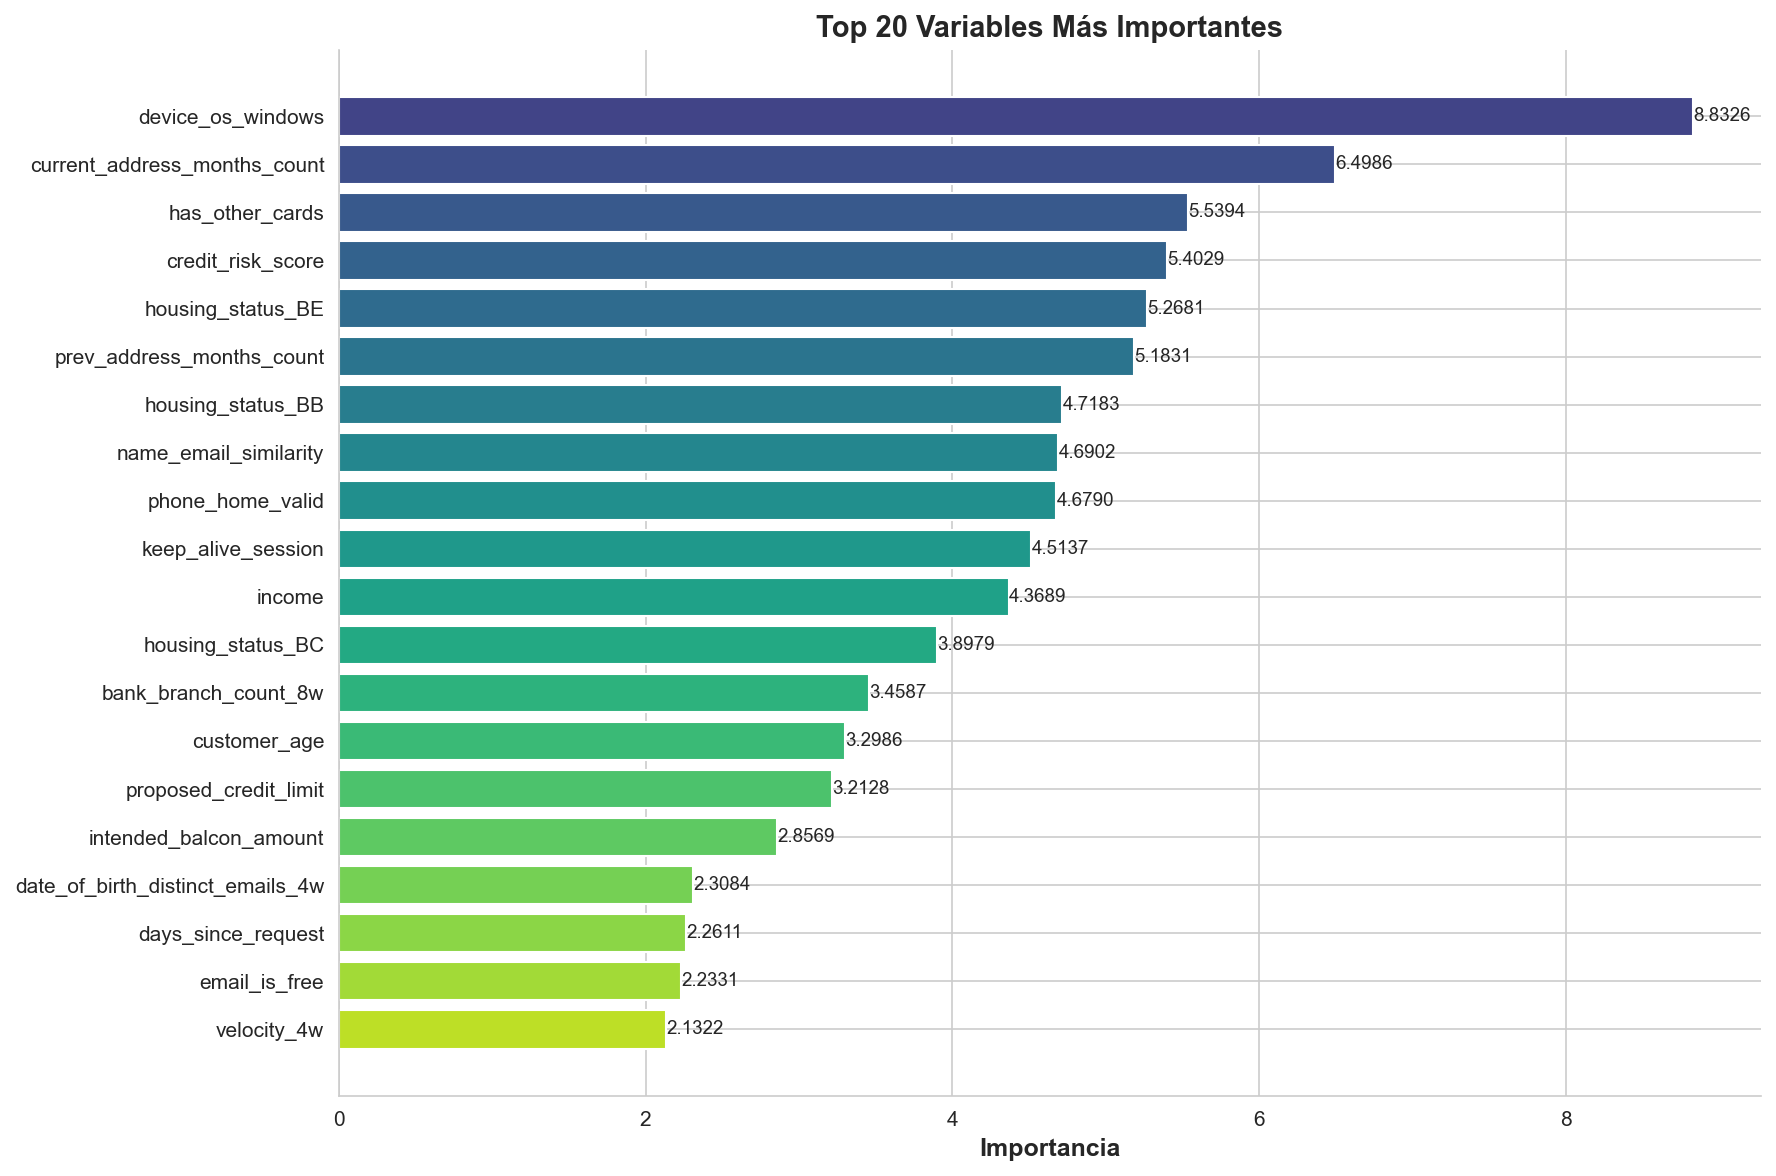

Guardado: img/feature_importance.png


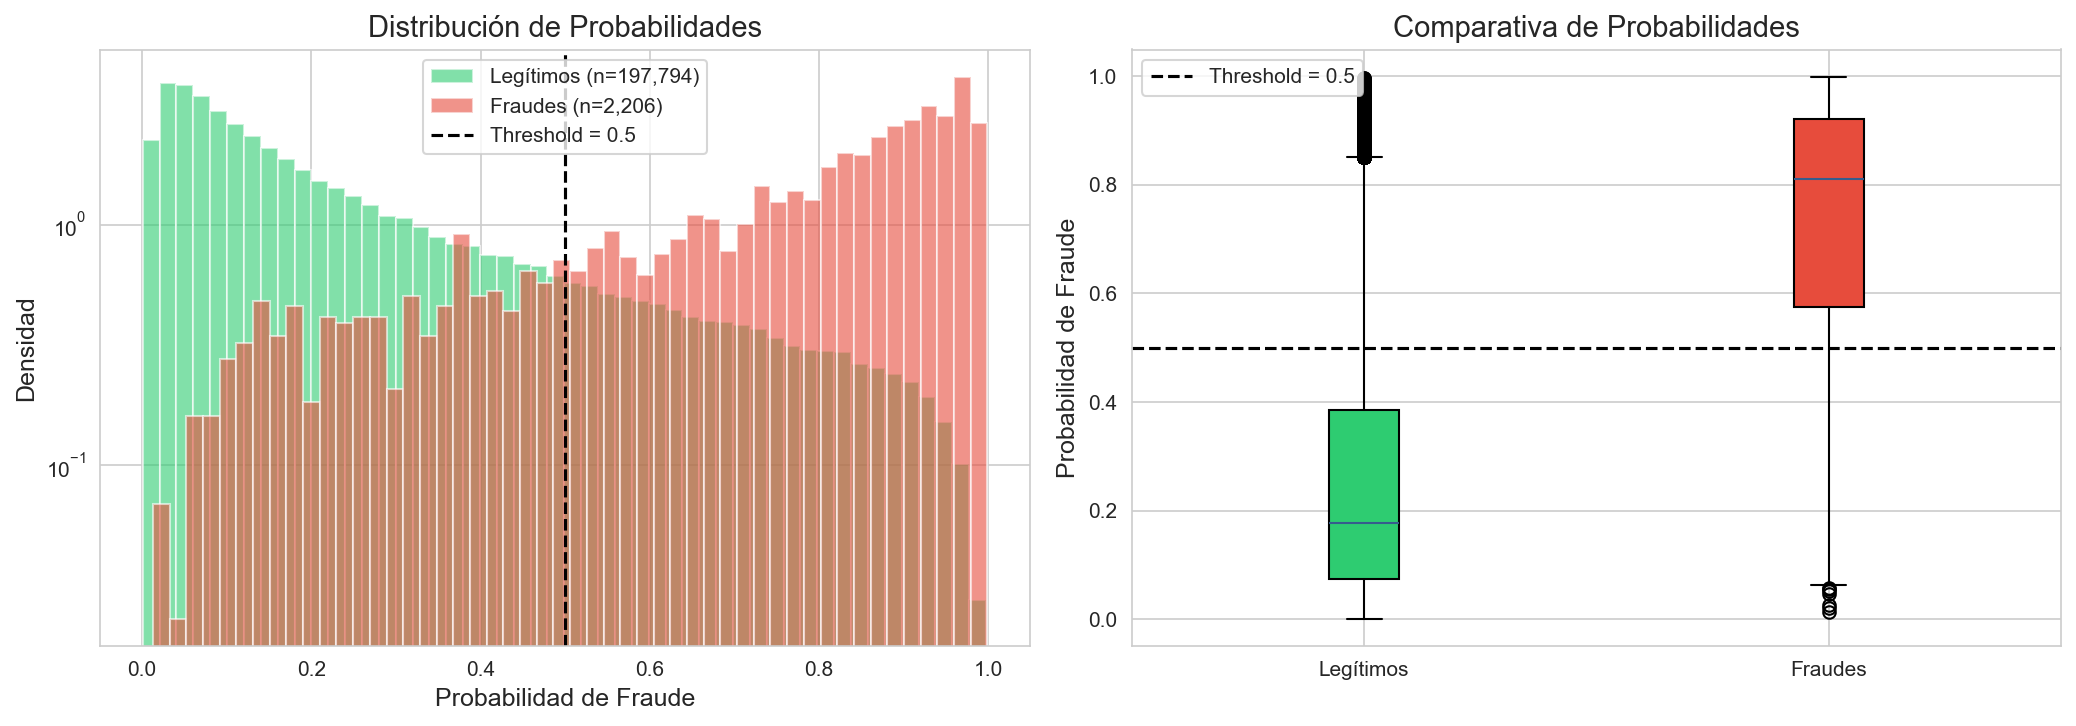

 Guardado: img/probability_distribution.png


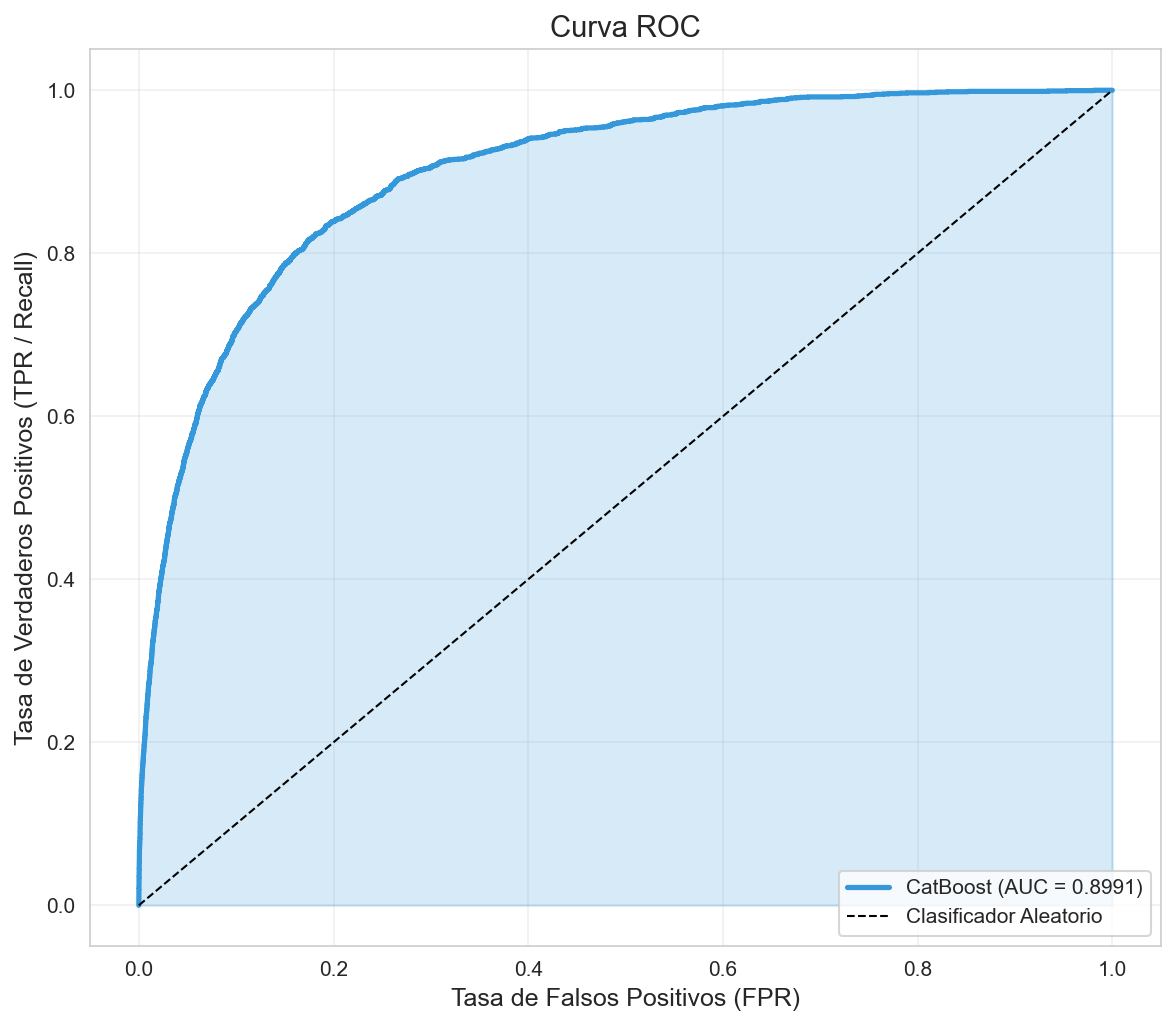

 Guardado: img/roc_curve.png


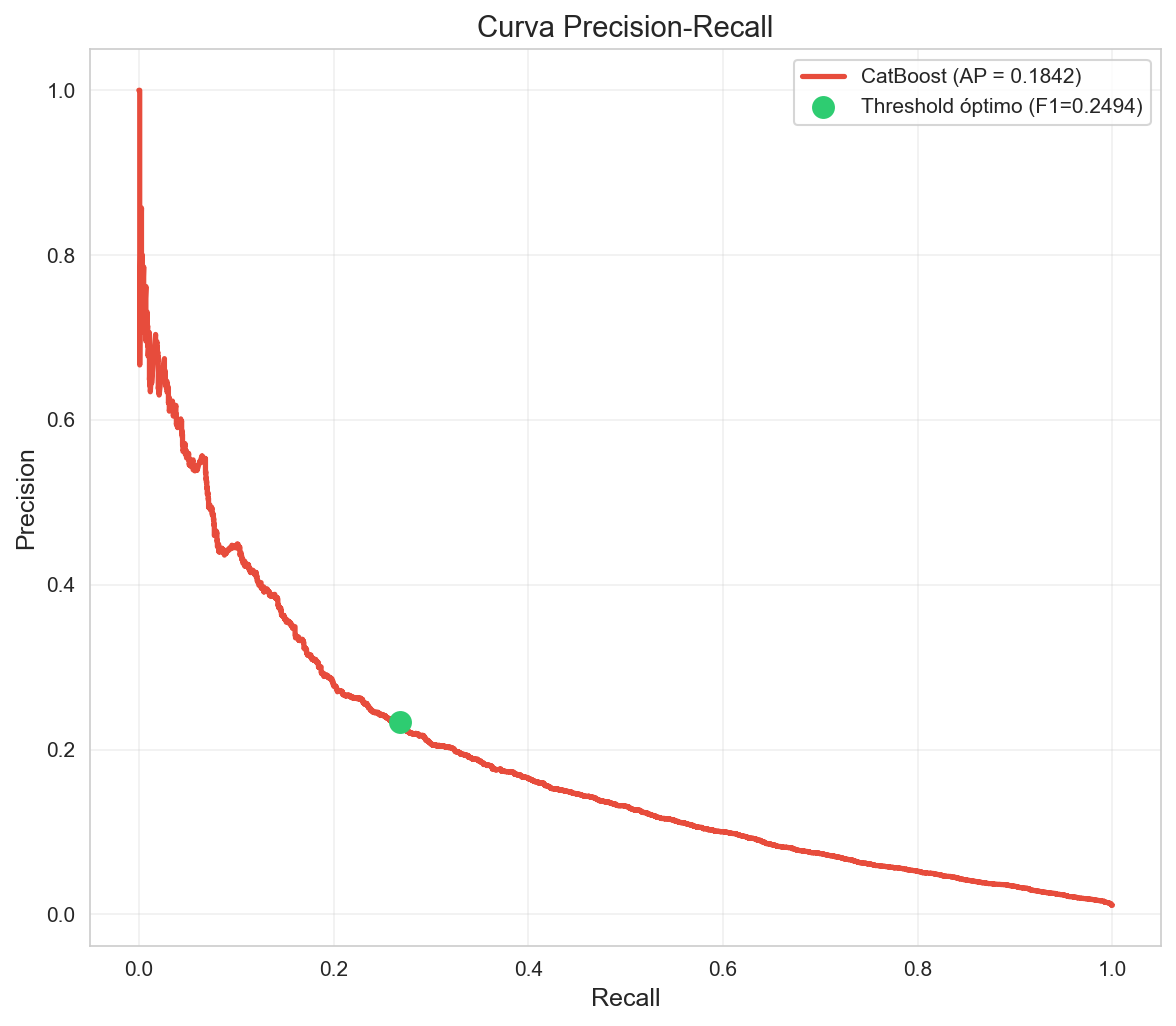

Guardado: img/pr_curve.png


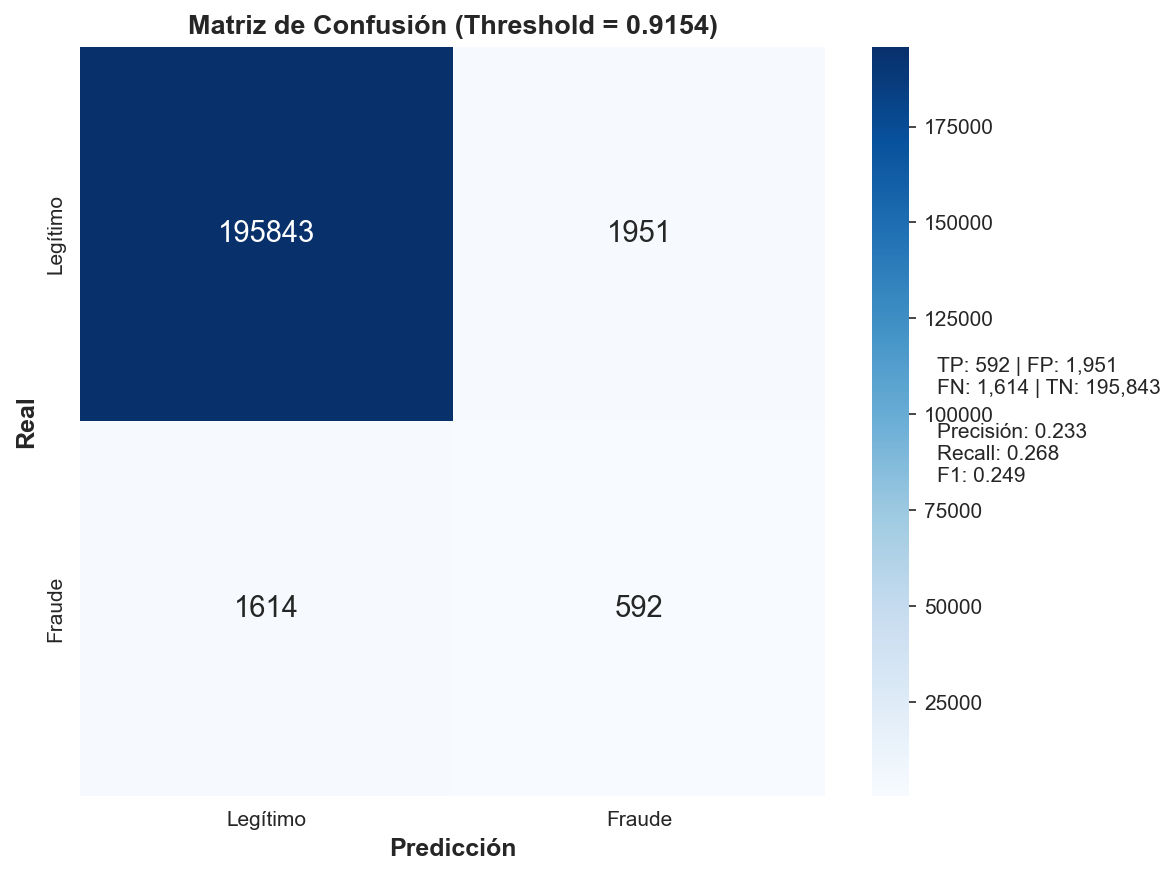

   Guardado: img/confusion_matrix.png


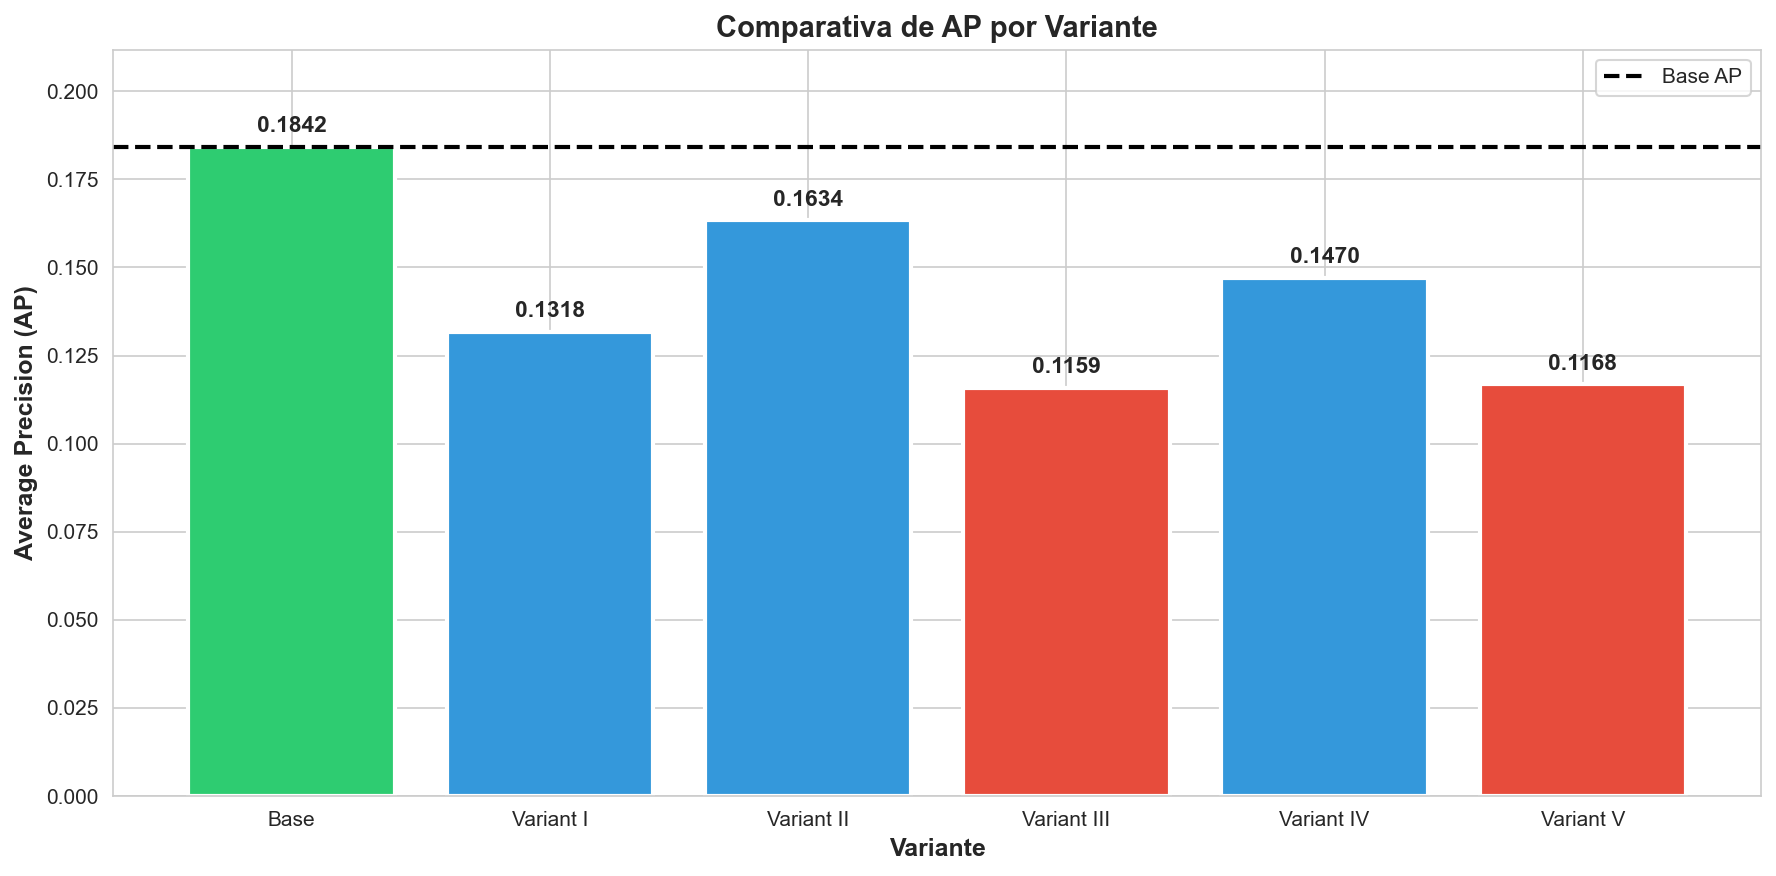

Guardado: img/variants_comparison.png


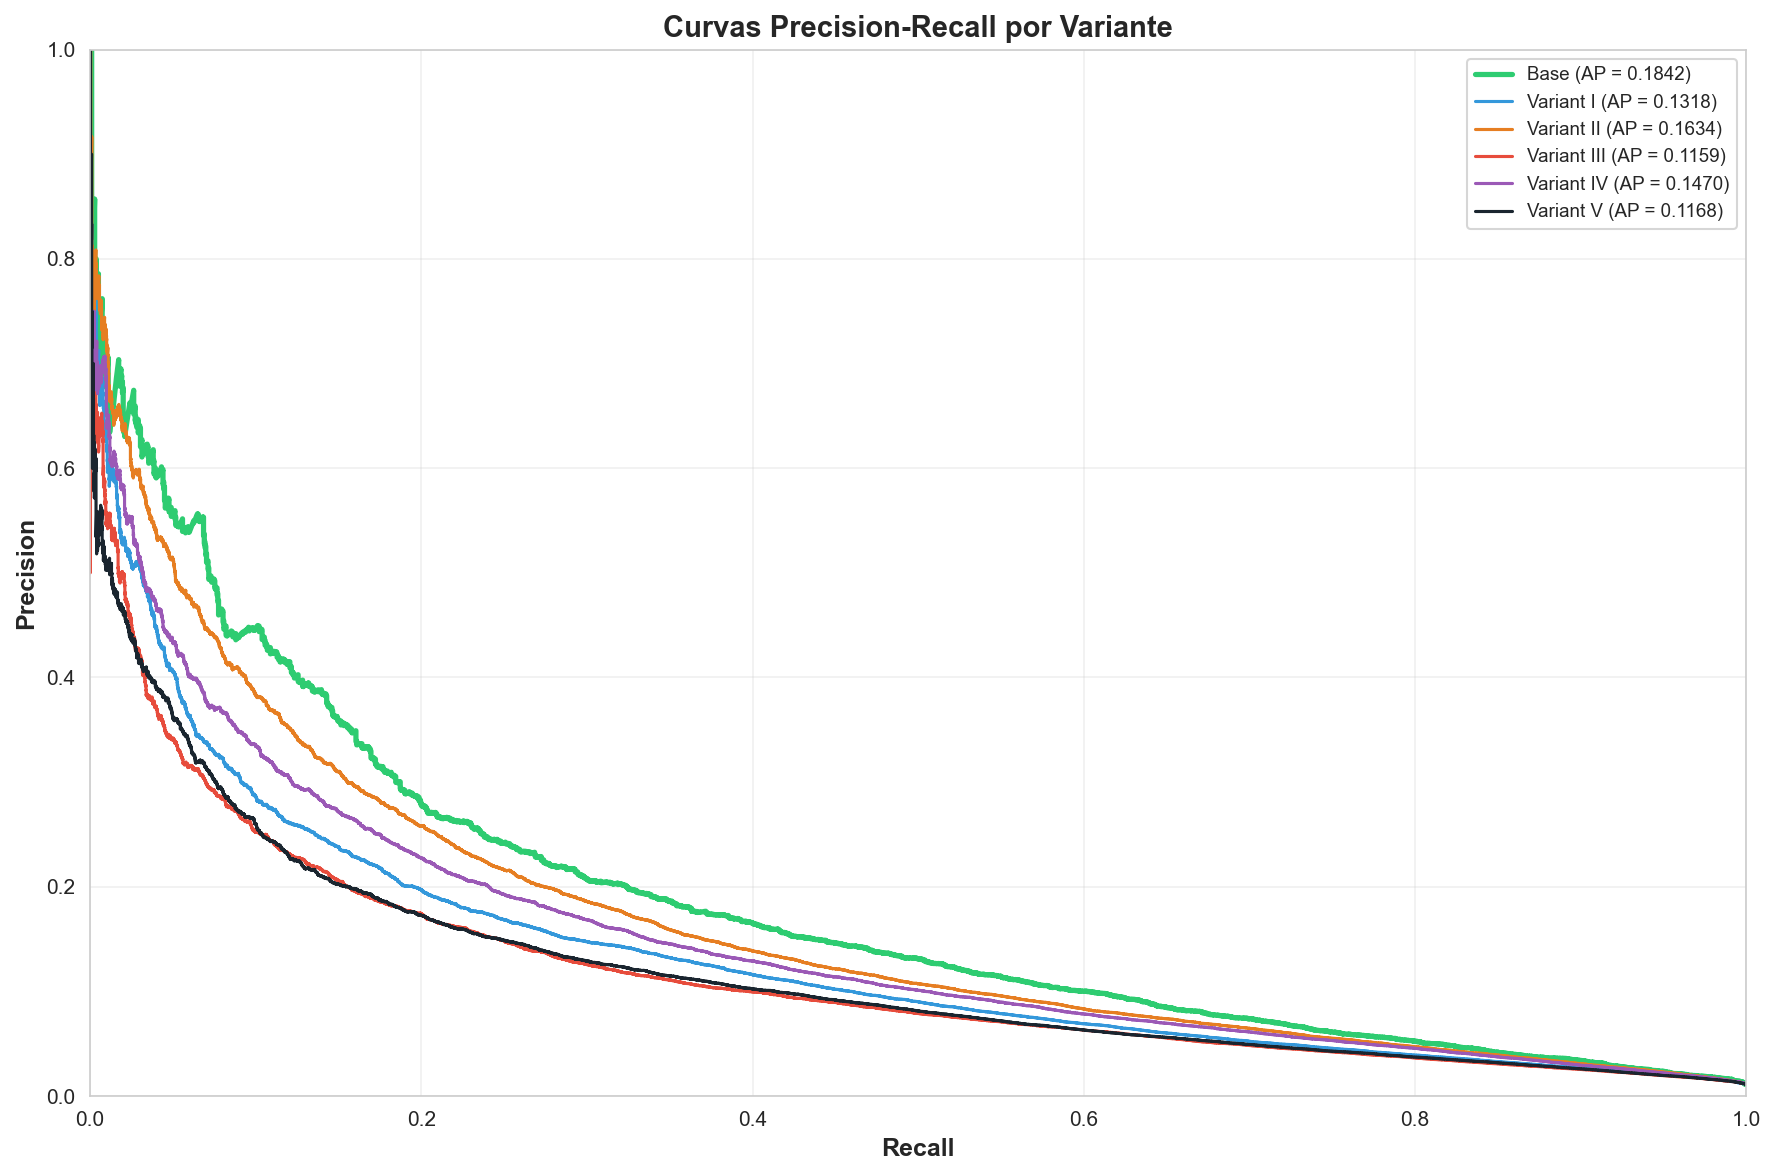

 Guardado: img/pr_curves_variants.png


In [36]:
generate_all_plots(
    final_pipeline=final_pipeline,
    X_train=X_train,
    X_test_base=X_test_base,
    y_test_base=y_test_base,
    all_results=all_results,
    df_results=df_results,
    output_dir='img/'
)

### 7.2 Gráficas adicionales de detalle

Un segundo bloque de gráficos con mayor resolución y orientación más narrativa, pensados para incluirse en una presentación o informe. 
Primero actualizamos la configuración de matplotlib para trabajar a mayor DPI y con etiquetas más grandes.

In [24]:
# Configuración estética
plt.rcParams.update({
    'figure.dpi': 150,          
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 15,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'figure.titlesize': 16,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--', 'grid.alpha': 0.6})

Generamos dos gráficos premium sobre el conjunto de test de Base:

1. **Curva PR con punto operativo** — la curva completa con el umbral óptimo marcado y una caja de texto que muestra el Recall y la Precision en ese punto.
2. **Densidad de probabilidades por clase** — distribuciones KDE superpuestas de las probabilidades predichas para legítimos y fraudes, 
con la línea de umbral de corte. Es el gráfico más intuitivo para ver si el modelo separa bien las dos clases.

📊 GENERANDO PLOTS PREMIUM PARA PRESENTACIÓN
1. Generando Curva Precision-Recall de Negocio...


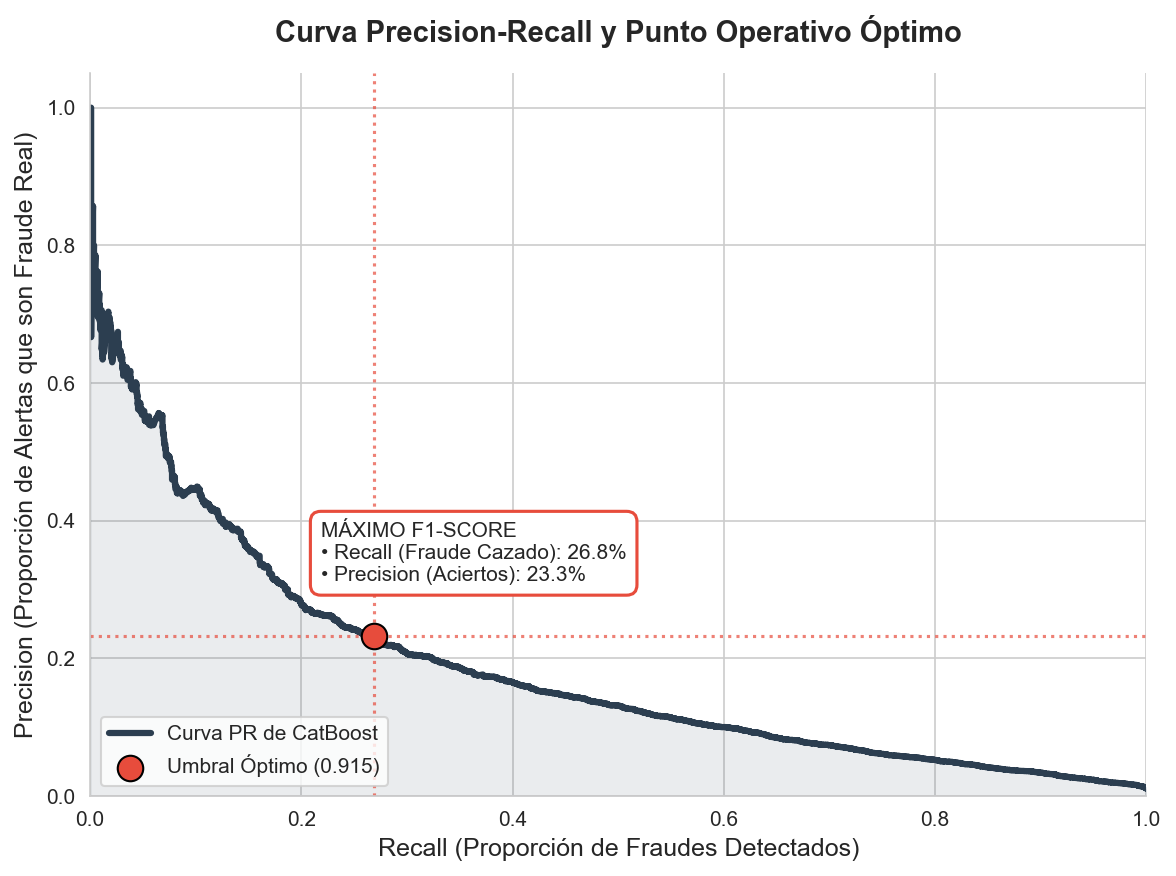

2. Generando Gráfico de Densidades...


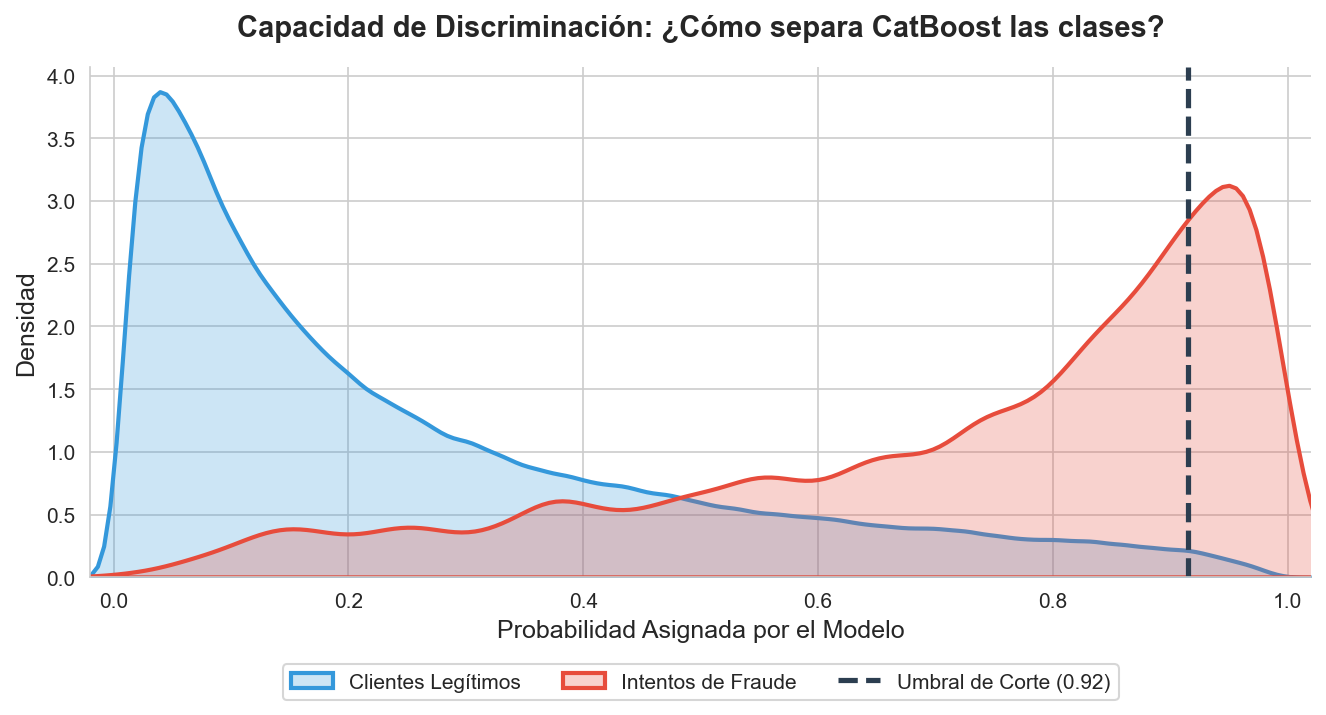

In [37]:
print("=" * 70)
print("📊 GENERANDO PLOTS PREMIUM PARA PRESENTACIÓN")
print("=" * 70)

y_proba_final = final_pipeline.predict_proba(X_test_base)[:, 1]

# Variables globales obtenidas de tu pipeline
best_thr = all_results[0]['Threshold']  # El umbral óptimo de la Base
y_pred = (y_proba_final >= best_thr).astype(int)

# Gráfico 1: Curva Precision-Recall con Punto Óptimo
print("1. Generando Curva Precision-Recall de Negocio...")

precision, recall, thresholds = precision_recall_curve(y_test_base, y_proba_final)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2c3e50', linewidth=3, label='Curva PR de CatBoost')
plt.fill_between(recall, precision, alpha=0.1, color='#34495e')

# Encontrar el índice del threshold que más se acerca a nuestro best_thr
idx_optimo = (np.abs(thresholds - best_thr)).argmin()

# Destacar el Punto de Operación
plt.scatter(recall[idx_optimo], precision[idx_optimo], color='#e74c3c', s=150, zorder=5,
            edgecolors='black', label=f'Umbral Óptimo ({best_thr:.3f})')

plt.axhline(y=precision[idx_optimo], color='#e74c3c', linestyle=':', alpha=0.7)
plt.axvline(x=recall[idx_optimo], color='#e74c3c', linestyle=':', alpha=0.7)

# Caja de texto llamativa
texto_metricas = (f"MÁXIMO F1-SCORE\n"
                  f"• Recall (Fraude Cazado): {recall[idx_optimo]*100:.1f}%\n"
                  f"• Precision (Aciertos): {precision[idx_optimo]*100:.1f}%")
plt.text(recall[idx_optimo] - 0.05, precision[idx_optimo] + 0.08, texto_metricas,
         bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="#e74c3c", lw=1.5), fontsize=10)

plt.title('Curva Precision-Recall y Punto Operativo Óptimo', pad=15, fontweight='bold')
plt.xlabel('Recall (Proporción de Fraudes Detectados)')
plt.ylabel('Precision (Proporción de Alertas que son Fraude Real)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left')
sns.despine()
plt.tight_layout()
plt.savefig('img/01_premium_pr_curve.png')
plt.show()

# Grafico 2: Densidad de Probabilidades por Clase
print("2. Generando Gráfico de Densidades...")

plt.figure(figsize=(9, 5))

# Asegurar que se usen arreglos 1D
y_proba_1d = np.array(y_proba_final).flatten()
y_test_1d = np.array(y_test_base).flatten()

# Densidades superpuestas
sns.kdeplot(y_proba_1d[y_test_1d == 0], fill=True, color="#3498db", label="Clientes Legítimos", bw_adjust=0.5, linewidth=2)
sns.kdeplot(y_proba_1d[y_test_1d == 1], fill=True, color="#e74c3c", label="Intentos de Fraude", bw_adjust=0.5, linewidth=2)

# Línea del umbral
plt.axvline(best_thr, color='#2c3e50', linestyle='--', linewidth=2.5, label=f'Umbral de Corte ({best_thr:.2f})')

plt.title('Capacidad de Discriminación: ¿Cómo separa CatBoost las clases?', pad=15, fontweight='bold')
plt.xlabel('Probabilidad Asignada por el Modelo')
plt.ylabel('Densidad')
plt.xlim([-0.02, 1.02])
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)
sns.despine()
plt.tight_layout()
plt.savefig('img/02_premium_density_separation.png')
plt.show()


## 8. Explicaciones contrafactuales con DiCE

Los contrafactuales responden a la pregunta: *¿qué tendría que cambiar en este caso de fraude para que el modelo lo clasificara como legítimo?* 
Usamos la librería DiCE con el método genético, que busca las modificaciones mínimas necesarias para cruzar la frontera de decisión. 
Algunas variables se marcan como inmutables, edad, si es una solicitud extranjera, mes, porque no tiene sentido modificarlas.

La función devuelve tanto los contrafactuales completos como una tabla resumen de los cambios necesarios, 
coloreando en verde las reducciones y en rojo los aumentos.

In [38]:
def contrafactuales_fraude(
    df: pd.DataFrame,
    model,
    target: str = "fraud_bool",
    n_cf: int = 3,
    sample_fraud_idx: int = None,
    features_inmutables: list = None,
):
    """
    Dado un modelo entrenado y una fila de fraude (clase 1), genera n_cf
    contrafactuales que el modelo clasificaría como no fraude (clase 0).
    """
    if features_inmutables is None:
        # Fijamos las que no tiene sentido cambiar en fraude bancario
        features_inmutables = [
            "customer_age", "foreign_request", "month",
        ]

    # Separar features y target 
    X = df.drop(columns=[target])
    y = df[target]

    # Seleccionar una fila de fraude 
    if sample_fraud_idx is None:
        # Cogemos el primer fraude disponible en el dataframe proporcionado
        sample_fraud_idx = df[df[target] == 1].index[0]

    fila_fraude = X.loc[[sample_fraud_idx]]
    print(f"Fila seleccionada (Estafador Real): índice {sample_fraud_idx}")
    print(f"Predicción del modelo: {model.predict(fila_fraude)[0]} "
          f"(Probabilidad de fraude: {model.predict_proba(fila_fraude)[0][1]:.3f})\n")

    # Definir el objeto de datos para DiCE
    continuous_features = X.select_dtypes(include=["number"]).columns.tolist()
    
    data_dice = dice_ml.Data(
        dataframe=df,
        continuous_features=continuous_features,
        outcome_name=target,
    )

    # Envolver el modelo
    # DiCE maneja pipelines de sklearn sin problema
    model_dice = dice_ml.Model(model=model, backend="sklearn")

    # Crear el explicador y generar contrafactuales
    # Usamos 'genetic' para encontrar el cambio mínimo posible
    exp = Dice(data_dice, model_dice, method="genetic")

    cf = exp.generate_counterfactuals(
        query_instances=fila_fraude,
        total_CFs=n_cf,
        desired_class=0,                        
        features_to_vary=[
            c for c in X.columns if c not in features_inmutables
        ],
    )

    # Mostrar resultados
    cf_df = cf.cf_examples_list[0].final_cfs_df
    original = fila_fraude.copy()
    original[target] = 1

    print("=" * 60)
    print("INSTANCIA ORIGINAL (fraude = 1)")
    print("=" * 60)
    display(original)

    print("\n" + "=" * 60)
    print(f"CONTRAFACTUALES GENERADOS (objetivo: fraude = 0)")
    print("=" * 60)
    display(cf_df)

    # Tabla de cambios necesarios
    print("\n" + "=" * 60)
    print("CAMBIOS NECESARIOS POR CONTRAFACTUAL (EL CAMINO MÍNIMO)")
    print("=" * 60)

    cf_features = cf_df.drop(columns=[target], errors="ignore")

    cambios_list = []
    for i, cf_row in cf_features.iterrows():
        for col in X.columns:
            val_orig = float(original[col].values[0])
            val_cf   = float(cf_row[col])
            if not pd.isna(val_cf) and abs(val_orig - val_cf) > 1e-6:
                cambios_list.append({
                    "Contrafactual": f"CF {i+1}",
                    "Variable": col,
                    "Valor original": round(val_orig, 4),
                    "Valor propuesto": round(val_cf, 4),
                    "Cambio": round(val_cf - val_orig, 4),
                })

    cambios_df = pd.DataFrame(cambios_list)
    if not cambios_df.empty:
        display(
            cambios_df.style
            .map(lambda v: "color: green; font-weight: bold" if isinstance(v, float) and v < 0 
                     else ("color: red; font-weight: bold" if isinstance(v, float) and v > 0 else ""),
                 subset=["Cambio"])
            .set_caption("Verde = disminución, Rojo = aumento")
        )
    else:
        print("No se encontraron diferencias significativas.")

    return cf, cambios_df

Preparamos el DataFrame que necesita DiCE (features + target juntos) y llamamos a la función con un fraude de ejemplo. 
Se generarán 3 contrafactuales y se mostrará qué variables hay que cambiar, y en cuánto, para que el modelo deje de considerarlo fraude.

In [39]:
# Unimos X_test y y_test para crear el dataframe que pide DiCE
df_dice = X_test_base.copy()
df_dice['fraud_bool'] = y_test_base

# Llamamos a la función para generar contrafactuales y mostrar los cambios necesarios
cf_result, cambios_df = contrafactuales_fraude(
    df=df_dice,
    model=final_pipeline,
    target="fraud_bool",
    n_cf=3,
    features_inmutables=["customer_age", "foreign_request", "month"]
)

Fila seleccionada (Estafador Real): índice 665979
Predicción del modelo: 1 (Probabilidad de fraude: 0.781)



100%|██████████| 1/1 [00:05<00:00,  5.14s/it]

INSTANCIA ORIGINAL (fraude = 1)


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11,fraud_bool
665979,0.9,0.850127,-1,117,40,0.012114,-1.282045,1002,1542.05939,3174.914896,...,0,0,0,0,0,1,0,0,0,1



CONTRAFACTUALES GENERADOS (objetivo: fraude = 0)


,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,velocity_24h,...,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11,fraud_bool
0,0.3,0.923275,-1,116,40,1.001040e-02,-1.063264,1045,1370.4397,3377.2559,...,0,1,0,0,0,1,0,0,0,0
0,0.1,0.923275,-1,116,40,2.343414e-02,-1.063264,963,1791.3035,1300.3074,...,0,0,0,0,0,0,0,0,0,0
0,0.6,0.832346,-1,0,40,6.500000e-08,-0.976449,2,-122.0717,3379.1343,...,0,0,0,0,0,0,0,0,0,0



CAMBIOS NECESARIOS POR CONTRAFACTUAL (EL CAMINO MÍNIMO)


,Contrafactual,Variable,Valor original,Valor propuesto,Cambio
0,CF 1,income,0.900000,0.300000,-0.600000
1,CF 1,name_email_similarity,0.850100,0.923300,0.073100
2,CF 1,current_address_months_count,117.000000,116.000000,-1.000000
3,CF 1,days_since_request,0.012100,0.010000,-0.002100
4,CF 1,intended_balcon_amount,-1.282000,-1.063300,0.218800
5,CF 1,zip_count_4w,1002.000000,1045.000000,43.000000
6,CF 1,velocity_6h,1542.059400,1370.439700,-171.619700
7,CF 1,velocity_24h,3174.914900,3377.255900,202.341000
8,CF 1,velocity_4w,3958.017400,4004.934800,46.917400
9,CF 1,bank_branch_count_8w,11.000000,10.000000,-1.000000



## 9. Auditoría detallada sobre múltiples fraudes

Ahora, ampliamos el análisis contrafactual a varios casos de fraude a la vez. 
Para cada uno generamos 3 opciones de contrafactuales y mostramos los 10 cambios de mayor magnitud de cada opción. 
Al final se imprime un resumen ejecutivo con todos los casos analizados, el número de cambios necesarios y las variables más afectadas. 
Esto permite detectar qué variables son las más explotables desde la perspectiva de un atacante.

In [40]:
def auditoria_detallada(df_base, pipeline_modelo, target_col, n_fraudes=5, top_cambios=10):
    """
    Analiza múltiples fraudes y muestra DETALLADAMENTE qué cambiar.
    
    Parámetros:
    - n_fraudes: número de fraudes a analizar
    - top_cambios: mostrar solo los cambios más importantes
    """
    
    fraudes = df_base[df_base[target_col] == 1].index.tolist()[:n_fraudes]
    
    resultados_totales = []
    
    for idx in fraudes:
        print(f"\n{'='*80}")
        print(f"🔍 ANALIZANDO FRAUDE {idx}")
        print(f"{'='*80}")
        
        X = df_base.drop(columns=[target_col])
        fila = X.loc[[idx]]
        
        proba_original = pipeline_modelo.predict_proba(fila)[0][1]
        print(f" Probabilidad de fraude actual: {proba_original * 100:.2f}%")
        
        # Configurar DiCE
        cont_feats = X.select_dtypes(include=["number"]).columns.tolist()
        data_dice = dice_ml.Data(dataframe=df_base, continuous_features=cont_feats, outcome_name=target_col)
        model_dice = dice_ml.Model(model=pipeline_modelo, backend="sklearn")
        exp = Dice(data_dice, model_dice, method="genetic")
        
        try:
            cf = exp.generate_counterfactuals(
                query_instances=fila,
                total_CFs=3,
                desired_class=0,
                features_to_vary=cont_feats
            )
            
            cf_df = cf.cf_examples_list[0].final_cfs_df
            cf_features = cf_df.drop(columns=[target_col], errors="ignore")
            
            # Analizar CADA contrafactual
            for cf_idx, cf_row in cf_features.iterrows():
                cambios = []
                for col in cont_feats:
                    val_orig = float(fila[col].values[0])
                    val_cf = float(cf_row[col])
                    if abs(val_orig - val_cf) > 1e-4:
                        cambios.append({
                            'Variable': col,
                            'Valor Original': round(val_orig, 4),
                            'Valor Propuesto': round(val_cf, 4),
                            'Cambio': round(val_cf - val_orig, 4),
                            '|Cambio|': abs(val_cf - val_orig)
                        })
                
                # Ordenar por magnitud de cambio (más importantes primero)
                cambios.sort(key=lambda x: x['|Cambio|'], reverse=True)
                
                print(f"\n Opción {cf_idx + 1} - Cambios necesarios: {len(cambios)}")
                print(f"   (Mostrando top {min(top_cambios, len(cambios))} cambios más importantes)")
                
                # Mostrar tabla de cambios
                df_cambios = pd.DataFrame(cambios[:top_cambios])
                display(
                    df_cambios.style
                    .map(lambda v: "color: #27ae60; font-weight: bold" if isinstance(v, float) and v < 0 
                         else ("color: #e74c3c; font-weight: bold" if isinstance(v, float) and v > 0 else ""),
                         subset=['Cambio'])
                    .format({'Valor Original': '{:.4f}', 'Valor Propuesto': '{:.4f}', 
                            'Cambio': '{:+.4f}', '|Cambio|': '{:.4f}'})
                    .set_caption(f"🔴 Rojo = Aumentar | 🟢 Verde = Reducir")
                )
                
                # Guardar para resumen
                resultados_totales.append({
                    'Índice': idx,
                    'Opción': cf_idx + 1,
                    'N° Cambios': len(cambios),
                    'Top_3_Cambios': ', '.join([f"{c['Variable']}({c['Cambio']:+.2f})" for c in cambios[:3]]),
                    'Probabilidad_Original': proba_original
                })
            
        except Exception as e:
            print(f"No se encontraron contrafactuales para este fraude")
            print(f"   Error: {str(e)[:200]}")
            resultados_totales.append({
                'Índice': idx,
                'Vulnerable': False,
                'Error': str(e)[:100]
            })
    
    # Resumen final
    print(f"\n{'='*80}")
    print("📊 RESUMEN DE VULNERABILIDADES DETECTADAS")
    print(f"{'='*80}")
    
    df_resumen = pd.DataFrame(resultados_totales)
    if len(df_resumen) > 0:
        print(df_resumen.to_string(index=False))
    
    return resultados_totales

Construimos el DataFrame de auditoría uniendo el test de Base con su etiqueta para pasárselo a DiCE.

In [42]:
df_auditoria = X_test_base.copy()
df_auditoria['fraud_bool'] = y_test_base

Lanzamos la auditoría sobre los primeros 5 fraudes del conjunto de test, mostrando hasta 10 cambios por contrafactual.

In [43]:
print("=" * 80)
print("🔍 AUDITORÍA DETALLADA - Mostrando QUÉ cambiar en cada fraude")
print("=" * 80)

resultados_detallados = auditoria_detallada(
    df_base=df_auditoria,
    pipeline_modelo=final_pipeline,
    target_col="fraud_bool",
    n_fraudes=5, 
    top_cambios=10 
)

🔍 AUDITORÍA DETALLADA - Mostrando QUÉ cambiar en cada fraude

🔍 ANALIZANDO FRAUDE 665979
 Probabilidad de fraude actual: 78.05%


100%|██████████| 1/1 [00:04<00:00,  4.18s/it]


 Opción 1 - Cambios necesarios: 18
   (Mostrando top 10 cambios más importantes)


,Variable,Valor Original,Valor Propuesto,Cambio,|Cambio|
0,velocity_6h,1542.0594,1380.8135,-161.2459,161.2459
1,zip_count_4w,1002.0000,1094.0000,+92.0000,92.0000
2,velocity_24h,3174.9149,3255.3853,+80.4704,80.4704
3,current_address_months_count,117.0000,59.0000,-58.0000,58.0000
4,credit_risk_score,108.0000,139.0000,+31.0000,31.0000
5,bank_months_count,31.0000,1.0000,-30.0000,30.0000
6,date_of_birth_distinct_emails_4w,11.0000,5.0000,-6.0000,6.0000
7,velocity_4w,3958.0174,3952.5781,-5.4393,5.4393
8,session_length_in_minutes,6.2063,1.7000,-4.5063,4.5063
9,bank_branch_count_8w,11.0000,9.0000,-2.0000,2.0000



 Opción 1 - Cambios necesarios: 18
   (Mostrando top 10 cambios más importantes)


...


 Opción 1 - Cambios necesarios: 16
   (Mostrando top 10 cambios más importantes)


,Variable,Valor Original,Valor Propuesto,Cambio,|Cambio|
0,zip_count_4w,2115.0000,1792.0000,-323.0000,323.0000
1,velocity_6h,8158.2203,7898.4185,-259.8018,259.8018
2,bank_branch_count_8w,211.0000,45.0000,-166.0000,166.0000
3,credit_risk_score,85.0000,173.0000,+88.0000,88.0000
4,velocity_4w,6706.3187,6631.2534,-75.0653,75.0653
5,current_address_months_count,94.0000,26.0000,-68.0000,68.0000
6,session_length_in_minutes,28.1078,8.3000,-19.8078,19.8078
7,velocity_24h,6730.0474,6721.5591,-8.4883,8.4883
8,date_of_birth_distinct_emails_4w,7.0000,15.0000,+8.0000,8.0000
9,bank_months_count,19.0000,15.0000,-4.0000,4.0000



 Opción 1 - Cambios necesarios: 16
   (Mostrando top 10 cambios más importantes)


,Variable,Valor Original,Valor Propuesto,Cambio,|Cambio|
0,velocity_24h,6730.0474,7003.0825,+273.0351,273.0351
1,bank_branch_count_8w,211.0000,11.0000,-200.0000,200.0000
2,zip_count_4w,2115.0000,1939.0000,-176.0000,176.0000
3,velocity_6h,8158.2203,8315.7529,+157.5326,157.5326
4,current_address_months_count,94.0000,149.0000,+55.0000,55.0000
5,intended_balcon_amount,49.3782,0.0156,-49.3626,49.3626
6,session_length_in_minutes,28.1078,4.9000,-23.2078,23.2078
7,credit_risk_score,85.0000,107.0000,+22.0000,22.0000
8,bank_months_count,19.0000,1.0000,-18.0000,18.0000
9,customer_age,50.0000,40.0000,-10.0000,10.0000



📊 RESUMEN DE VULNERABILIDADES DETECTADAS
 Índice  Opción  N° Cambios                                                                                    Top_3_Cambios  Probabilidad_Original
 665979       1          18                                 velocity_6h(-161.25), zip_count_4w(+92.00), velocity_24h(+80.47)               0.780543
 665979       1          18                                 velocity_24h(+202.34), velocity_6h(-171.62), velocity_4w(+46.92)               0.780543
 665979       1          18                  current_address_months_count(-88.00), zip_count_4w(-82.00), velocity_4w(-80.70)               0.780543
 807741       1          16                   zip_count_4w(-1254.00), velocity_24h(-1197.88), proposed_credit_limit(-310.00)               0.648076
 807741       1          16                              velocity_6h(-3372.00), velocity_24h(+260.47), zip_count_4w(-182.00)               0.648076
 807741       1          16                              velocity_6h(-


## 10. Patrones de evasión detectados

A partir de los resultados de la auditoría, consolidamos los hallazgos en visualizaciones de resumen. 
Usamos datos extraídos manualmente de los contrafactuales generados para los 5 fraudes analizados.

### 10.1 Relación entre probabilidad de fraude y esfuerzo de evasión

El primer gráfico muestra si existe correlación entre lo convencido que está el modelo de que algo es fraude (probabilidad alta) 
y el número mínimo de cambios que necesitaría un atacante para engañarlo. 
El segundo gráfico muestra qué variables aparecen con más frecuencia entre los cambios necesarios, 
las candidatas más evidentes de reforzar en el modelo.

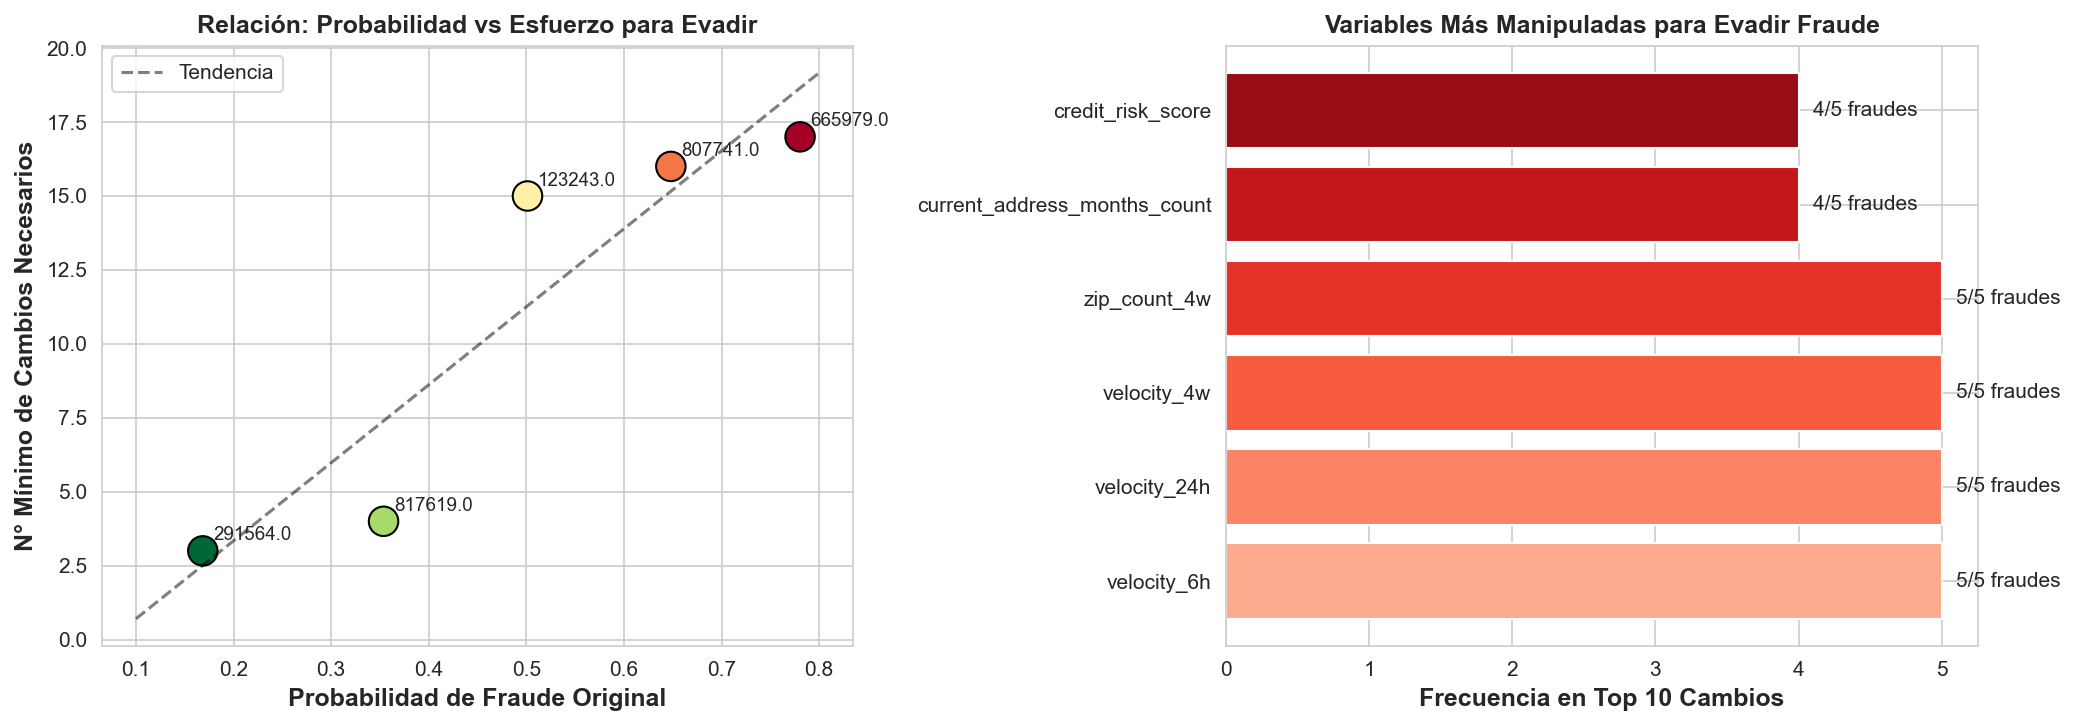

In [44]:
datos = pd.DataFrame({
    'Fraude': [665979, 665979, 665979, 807741, 807741, 807741, 
               291564, 291564, 291564, 817619, 817619, 817619, 
               123243, 123243, 123243],
    'Probabilidad': [0.7805, 0.7805, 0.7805, 0.6481, 0.6481, 0.6481,
                     0.1685, 0.1685, 0.1685, 0.3537, 0.3537, 0.3537,
                     0.5012, 0.5012, 0.5012],
    'Cambios': [18, 17, 17, 16, 17, 17, 3, 13, 15, 4, 17, 16, 15, 15, 15]
})

# Agrupar por fraude (tomar mínimo de cambios)
min_cambios = datos.groupby('Fraude')['Cambios'].min().reset_index()
min_cambios['Probabilidad'] = datos.groupby('Fraude')['Probabilidad'].first().values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Probabilidad vs Cambios necesarios
ax1.scatter(min_cambios['Probabilidad'], min_cambios['Cambios'], 
            s=200, c=min_cambios['Probabilidad'], cmap='RdYlGn_r', edgecolor='black')
ax1.set_xlabel('Probabilidad de Fraude Original', fontsize=12, fontweight='bold')
ax1.set_ylabel('N° Mínimo de Cambios Necesarios', fontsize=12, fontweight='bold')
ax1.set_title('Relación: Probabilidad vs Esfuerzo para Evadir', fontsize=12, fontweight='bold')

# Añadir etiquetas
for i, row in min_cambios.iterrows():
    ax1.annotate(str(row['Fraude']), (row['Probabilidad'], row['Cambios']),
                xytext=(5, 5), textcoords='offset points', fontsize=9)

# Línea de tendencia
z = np.polyfit(min_cambios['Probabilidad'], min_cambios['Cambios'], 1)
p = np.poly1d(z)
ax1.plot([0.1, 0.8], p([0.1, 0.8]), 'k--', alpha=0.5, label='Tendencia')
ax1.legend()

# Gráfico 2: Heatmap de variables más afectadas
ax2 = ax2
variables = ['velocity_6h', 'velocity_24h', 'velocity_4w', 'zip_count_4w', 
             'current_address_months_count', 'credit_risk_score']
frecuencia = [5, 5, 5, 5, 4, 4]

colors = plt.cm.Reds(np.linspace(0.3, 0.9, len(variables)))
bars = ax2.barh(variables, frecuencia, color=colors, edgecolor='white')
ax2.set_xlabel('Frecuencia en Top 10 Cambios', fontsize=12, fontweight='bold')
ax2.set_title('Variables Más Manipuladas para Evadir Fraude', fontsize=12, fontweight='bold')

for bar, freq in zip(bars, frecuencia):
    ax2.text(freq + 0.1, bar.get_y() + bar.get_height()/2, 
             f'{freq}/5 fraudes', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('img/evasion_patterns.png', dpi=300, bbox_inches='tight')
plt.show()

### 10.2 Casos ilustrativos de rutas de evasión

Guardamos en un diccionario dos casos concretos que ilustran bien los extremos: uno con probabilidad baja (16.85%) que solo necesita 3 cambios mínimos, 
y otro con probabilidad alta (78.05%) que requiere modificaciones drásticas en varias variables de velocidad. 
Sirve como material de referencia para el análisis posterior.

In [45]:
casos = {
    "Fraude 291564 (16.85%)": {
        "cambios": [
            {"variable": "session_length_in_minutes", "direccion": "+0.05", "significado": "Aumentar duración de sesión"},
            {"variable": "velocity_4w", "direccion": "-0.0002", "significado": "Reducir velocidad (mínimo)"},
            {"variable": "velocity_6h", "direccion": "+0.0001", "significado": "Aumentar velocidad (mínimo)"}
        ]
    },
    "Fraude 665979 (78.05%)": {
        "cambios_principales": [
            {"variable": "velocity_6h", "direccion": "-161.25", "significado": "REDUCIR drásticamente velocidad 6h"},
            {"variable": "velocity_24h", "direccion": "+80.47", "significado": "AUMENTAR velocidad 24h"},
            {"variable": "zip_count_4w", "direccion": "+92", "significado": "AUMENTAR frecuencia zip"},
            {"variable": "current_address_months_count", "direccion": "-58", "significado": "REDUCIR tiempo en dirección"}
        ]
    }
}

### 10.3 Dirección de los cambios necesarios

Visualizamos para cada variable relevante si un atacante necesitaría aumentar o reducir su valor para evadir el modelo. 
Las barras rojas indican que hay que disminuir el valor, las verdes que hay que aumentarlo. 
Este gráfico es útil para priorizar qué señales reforzar en futuras iteraciones del modelo.

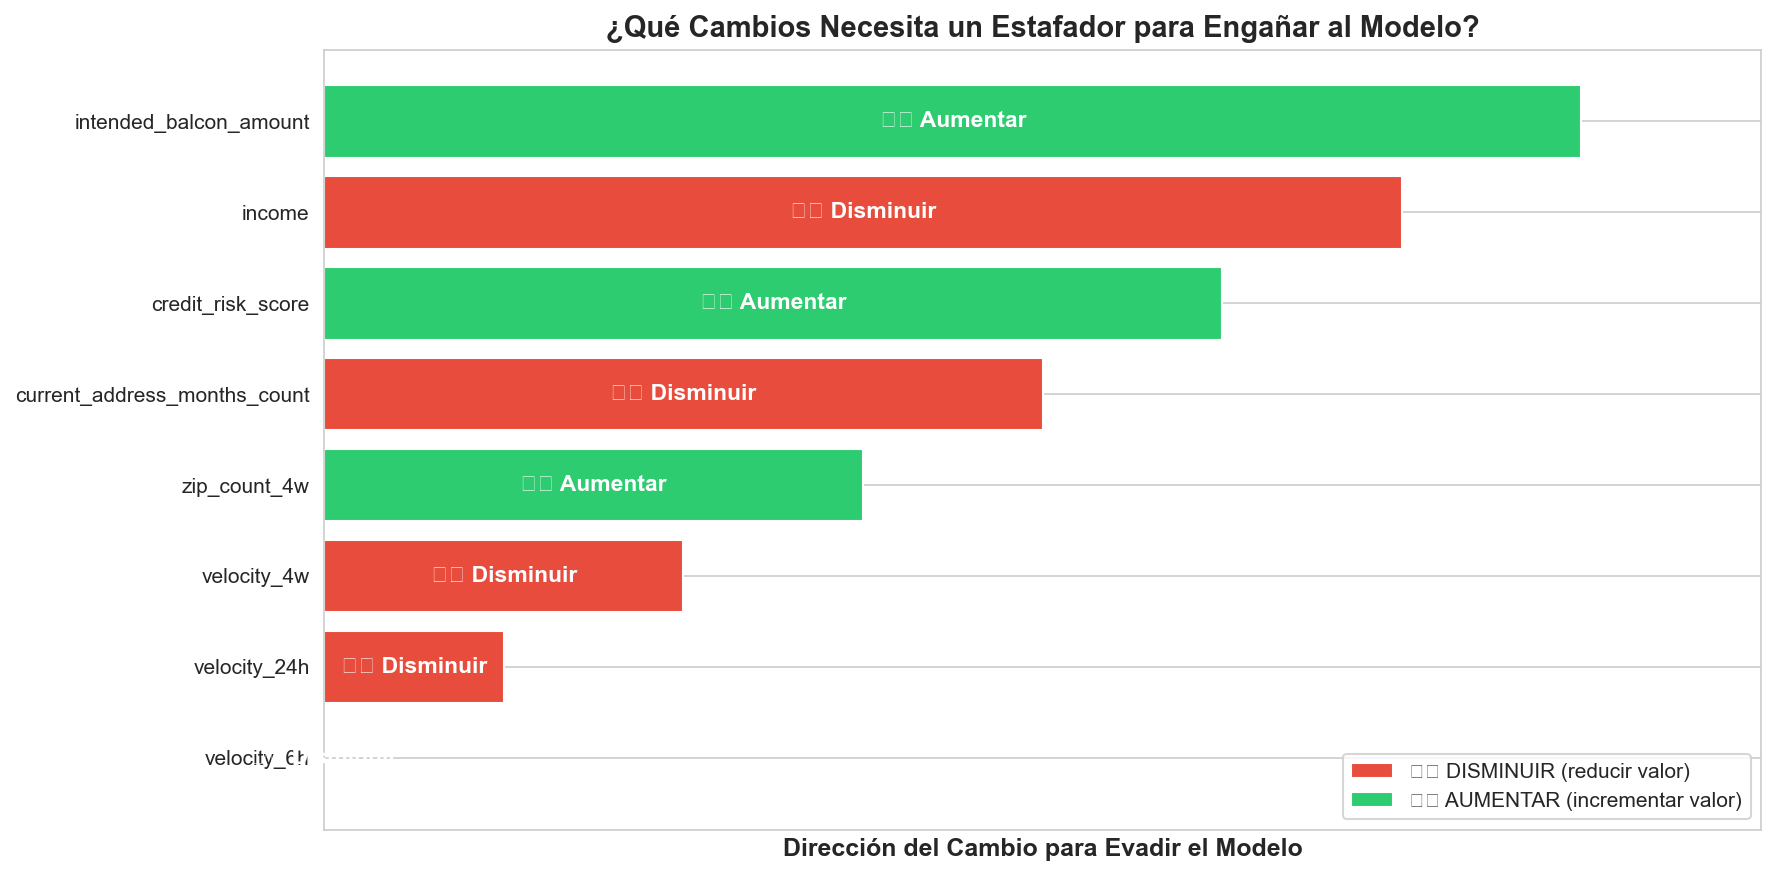

In [46]:
variables = ['velocity_6h', 'velocity_24h', 'velocity_4w', 
             'zip_count_4w', 'current_address_months_count', 
             'credit_risk_score', 'income', 'intended_balcon_amount']

direccion = ['⬇️ Disminuir', '⬇️ Disminuir', '⬇️ Disminuir',
             '⬆️ Aumentar', '⬇️ Disminuir',
             '⬆️ Aumentar', '⬇️ Disminuir', '⬆️ Aumentar']

colores = ['#e74c3c' if 'Disminuir' in d else '#2ecc71' for d in direccion]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(variables, range(len(variables)), color=colores, edgecolor='white')

# Añadir direcciones
for i, (bar, dir_text) in enumerate(zip(bars, direccion)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_y() + bar.get_height()/2,
            dir_text, ha='center', va='center', fontsize=11, fontweight='bold', color='white')

ax.set_xlabel('Dirección del Cambio para Evadir el Modelo', fontsize=12, fontweight='bold')
ax.set_title('¿Qué Cambios Necesita un Estafador para Engañar al Modelo?', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(range(len(variables))) + 1)
ax.set_xticks([])

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='⬇️ DISMINUIR (reducir valor)'),
    Patch(facecolor='#2ecc71', label='⬆️ AUMENTAR (incrementar valor)'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('img/direction_of_changes.png', dpi=300, bbox_inches='tight')
plt.show()

### 10.4 Tabla resumen: impacto de negocio de cada vulnerabilidad

Por último,se crea una tabla que traduce los hallazgos técnicos al lenguaje de negocio: qué significa cada cambio en términos prácticos 
y qué nivel de riesgo representa para el sistema de detección, distinguiendo entre variables fácilmente falsificables 
(como ingresos declarados o velocidad de transacciones) y las que requieren más esfuerzo o documentación por parte del atacante.

In [47]:
resumen_cambios = pd.DataFrame({
    'Variable': ['velocity_6h', 'velocity_24h', 'velocity_4w', 
                 'zip_count_4w', 'current_address_months_count', 
                 'credit_risk_score', 'income', 'intended_balcon_amount'],
    'Dirección': ['⬇ DISMINUIR', '⬇ DISMINUIR', '⬇ DISMINUIR',
                  '⬆ AUMENTAR', '⬇ DISMINUIR',
                  '⬆ AUMENTAR', '⬇ DISMINUIR', '⬆ AUMENTAR'],
    'Significado Negocio': [
        'Hacer menos transacciones en 6 horas',
        'Hacer menos transacciones en 24 horas',
        'Reducir actividad mensual',
        'Operar desde códigos postales más activos',
        'Cambiar de dirección más frecuentemente',
        'Mejorar historial crediticio',
        'Declarar ingresos más bajos',
        'Solicitar montos más altos'
    ],
    'Riesgo para el Negocio': [
        '🔴 ALTO - Fácil de manipular',
        '🔴 ALTO - Fácil de manipular',
        '🟡 MEDIO',
        '🟢 BAJO - Más difícil de falsificar',
        '🟡 MEDIO',
        '🟢 BAJO - Requiere documentación',
        '🔴 ALTO - Fácil de mentir',
        '🟡 MEDIO'
    ]
})

print("=" * 80)
print("GUÍA: QUÉ CAMBIAR Y EN QUÉ DIRECCIÓN")
print("=" * 80)
print(resumen_cambios.to_string(index=False))

GUÍA: QUÉ CAMBIAR Y EN QUÉ DIRECCIÓN
                    Variable   Dirección                       Significado Negocio             Riesgo para el Negocio
                 velocity_6h ⬇ DISMINUIR      Hacer menos transacciones en 6 horas        🔴 ALTO - Fácil de manipular
                velocity_24h ⬇ DISMINUIR     Hacer menos transacciones en 24 horas        🔴 ALTO - Fácil de manipular
                 velocity_4w ⬇ DISMINUIR                 Reducir actividad mensual                            🟡 MEDIO
                zip_count_4w  ⬆ AUMENTAR Operar desde códigos postales más activos 🟢 BAJO - Más difícil de falsificar
current_address_months_count ⬇ DISMINUIR   Cambiar de dirección más frecuentemente                            🟡 MEDIO
           credit_risk_score  ⬆ AUMENTAR              Mejorar historial crediticio    🟢 BAJO - Requiere documentación
                      income ⬇ DISMINUIR               Declarar ingresos más bajos           🔴 ALTO - Fácil de mentir
      intended_balc